In [1]:
import astropy.units as u
import astropy.constants as const
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from tqdm.notebook import tqdm
import json
import h5py
import os

import warnings
warnings.filterwarnings("ignore")

from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import LocallyIsothermalEOS  
from DiscEvolution.eos import SimpleDiscEOS
from DiscEvolution.eos import IrradiatedEOS  
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.viscous_evolution import ViscousEvolutionFV
from DiscEvolution.driver import PlanetDiscDriver
from DiscEvolution.io import Event_Controller
from DiscEvolution.dust import DustGrowthTwoPop, SingleFluidDrift
from DiscEvolution.viscous_evolution import HybridWindModel
from DiscEvolution.opacity import Zhu2012
from DiscEvolution.constants import yr as yr_code, GasConst, Omega0, AU, Msun  # DiscEvolution uses code units: 1 year = 2π code time units
from DiscEvolution.chemistry import SimpleCOAtomAbund, EquilibriumCOChemOberg
from DiscEvolution import planet_formation as pf
from DiscEvolution.diffusion import TracerDiffusion 
from DiscEvolution.planet_formation import Planets, Bitsch2015Model
from DiscEvolution.constants import *

In [2]:
def h5_to_dict(h5obj):
    out = {}
    for k, v in h5obj.items():
        if isinstance(v, h5py.Dataset):
            out[k] = v[()]          # load dataset into memory
        else:
            out[k] = h5_to_dict(v)  # recurse into group
    return out     

crPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/CR_2Myr/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260902_134052.h5"
xrPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/XR_2Myr/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260902_134206.h5"
# xrPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/HWFix/XR_0.1Myr/winds_mig_psi2.533e+01_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260907_175426.h5"
cxPath = "/Users/james/Documents/GitHub/DiscEvolution/james/september2026/output/CRXR_2Myr/winds_mig_psi10.0_Mdot1.0e-08_M1.0e-01_Rd5.0e+01_20260902_134222.h5"

print('\n  -------- data ---------')
with h5py.File(crPath, "r") as crf:
    CR = h5_to_dict(crf)
    CRattr = dict(crf.attrs)

for i in CR.keys():
    print(i)

with h5py.File(xrPath, "r") as xrf:
    XR = h5_to_dict(xrf)
    XRattr = dict(xrf.attrs)

with h5py.File(cxPath, "r") as cxf:
    CX = h5_to_dict(cxf)
    CXattr = dict(cxf.attrs)



  -------- data ---------
B_xe
C_xe
D_xe
H
JXR
Lambda
M_iso
M_transition
Mcs
Mes
NH
P
R
R_dz
R_dz_t
Rp
Sigc
Sigma_G
Sigma_dust
Sigma_grain_size
Sigma_pebble_size
Sigma_pebbles
Sigma_planetesimals
St
T
Tc
Vdrift
X_cores
X_envs
alpha_R
disk_Mass
disk_Mdot_p
disk_Mdot_star
disk_atom_gas_abund
disk_atom_ice_abund
disk_ice_lines
disk_mol_gas_abund
disk_mol_ice_abund
disk_planetesimal_atom_abund
disk_planetesimal_mol_abund
eta_diff
ice_lines
n_density
nu
psi_R
rho_mid
sigmaXR
t
tau_XR
time_snap
xe
zeta
zeta_CR
zeta_XR


In [3]:
crR = CR["R"]
crtsnap = CR["time_snap"]    # Myr        
crSigma_g = CR["Sigma_G"]   
crRdz = CR['R_dz_t']
crt = CR["t"]                # yr
crZeta = CR['zeta']
crZetaCR = CR['zeta_CR']
crZetaXR = CR['zeta_XR']
crLam = CR['Lambda']
crT = CR['T']
crxe = CR['xe']
creta = CR['eta_diff']
crn = CR['n_density']
cralpha = CR['alpha_R']
crpsi = CR['psi_R']

xrR = XR["R"]
xrtsnap = XR["time_snap"]    # Myr        
xrSigma_g = XR["Sigma_G"]   
xrRdz = XR['R_dz_t']
xrt = XR["t"]                # yr
xrZeta = XR['zeta']
xrZetaCR = XR['zeta_CR']
xrZetaXR = XR['zeta_XR']
xrLam = XR['Lambda']
xrT = XR['T']
xrxe = XR['xe']
xreta = XR['eta_diff']
xrn = XR['n_density']
xralpha = XR['alpha_R']
xrpsi = XR['psi_R']

cxR = CX["R"]
cxtsnap = CX["time_snap"]    # Myr        
cxSigma_g = CX["Sigma_G"]   
cxRdz = CX['R_dz_t']
cxt = CX["t"]                # yr
cxZeta = CX['zeta']
cxZetaCR = CX['zeta_CR']
cxZetaXR = CX['zeta_XR']
cxLam = CX['Lambda']
cxT = CX['T']
cxxe = CX['xe']
cxeta = CX['eta_diff']
cxn = CX['n_density']
cxalpha = CX['alpha_R']
cxpsi = CX['psi_R']

In [4]:
arr1 = crtsnap*1e6
arr2 = crt
idx = np.searchsorted(arr2, arr1)           # Find the insertion positions
idx = np.clip(idx, 1, len(arr2) - 1)        # Handle edge cases where the index falls outside array boundaries
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])   # Check whether the left or right neighbor is closer
closest_indices = np.where(left_closer, idx - 1, idx)
cridx = closest_indices
print(cridx)

arr1 = xrtsnap*1e6
arr2 = xrt
idx = np.searchsorted(arr2, arr1)           # Find the insertion positions
idx = np.clip(idx, 1, len(arr2) - 1)        # Handle edge cases where the index falls outside array boundaries
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])   # Check whether the left or right neighbor is closer
closest_indices = np.where(left_closer, idx - 1, idx)
xridx = closest_indices
print(xridx)

arr1 = cxtsnap*1e6
arr2 = cxt
idx = np.searchsorted(arr2, arr1)           # Find the insertion positions
idx = np.clip(idx, 1, len(arr2) - 1)        # Handle edge cases where the index falls outside array boundaries
left_closer = np.abs(arr1 - arr2[idx - 1]) < np.abs(arr1 - arr2[idx])   # Check whether the left or right neighbor is closer
closest_indices = np.where(left_closer, idx - 1, idx)
cxidx = closest_indices
print(cxidx)

print(crtsnap)

[    0   181  6408 12536 18894 24923 30906 36844 42655 47837]
[    0   181  6456 12827 18932 24985 30977 36915 42730 47912]
[    0   181  6408 12536 18896 24925 30907 36845 42657 47816]
[0.    0.005 0.25  0.5   0.75  1.    1.25  1.5   1.75  2.   ]


# Ionization Rates

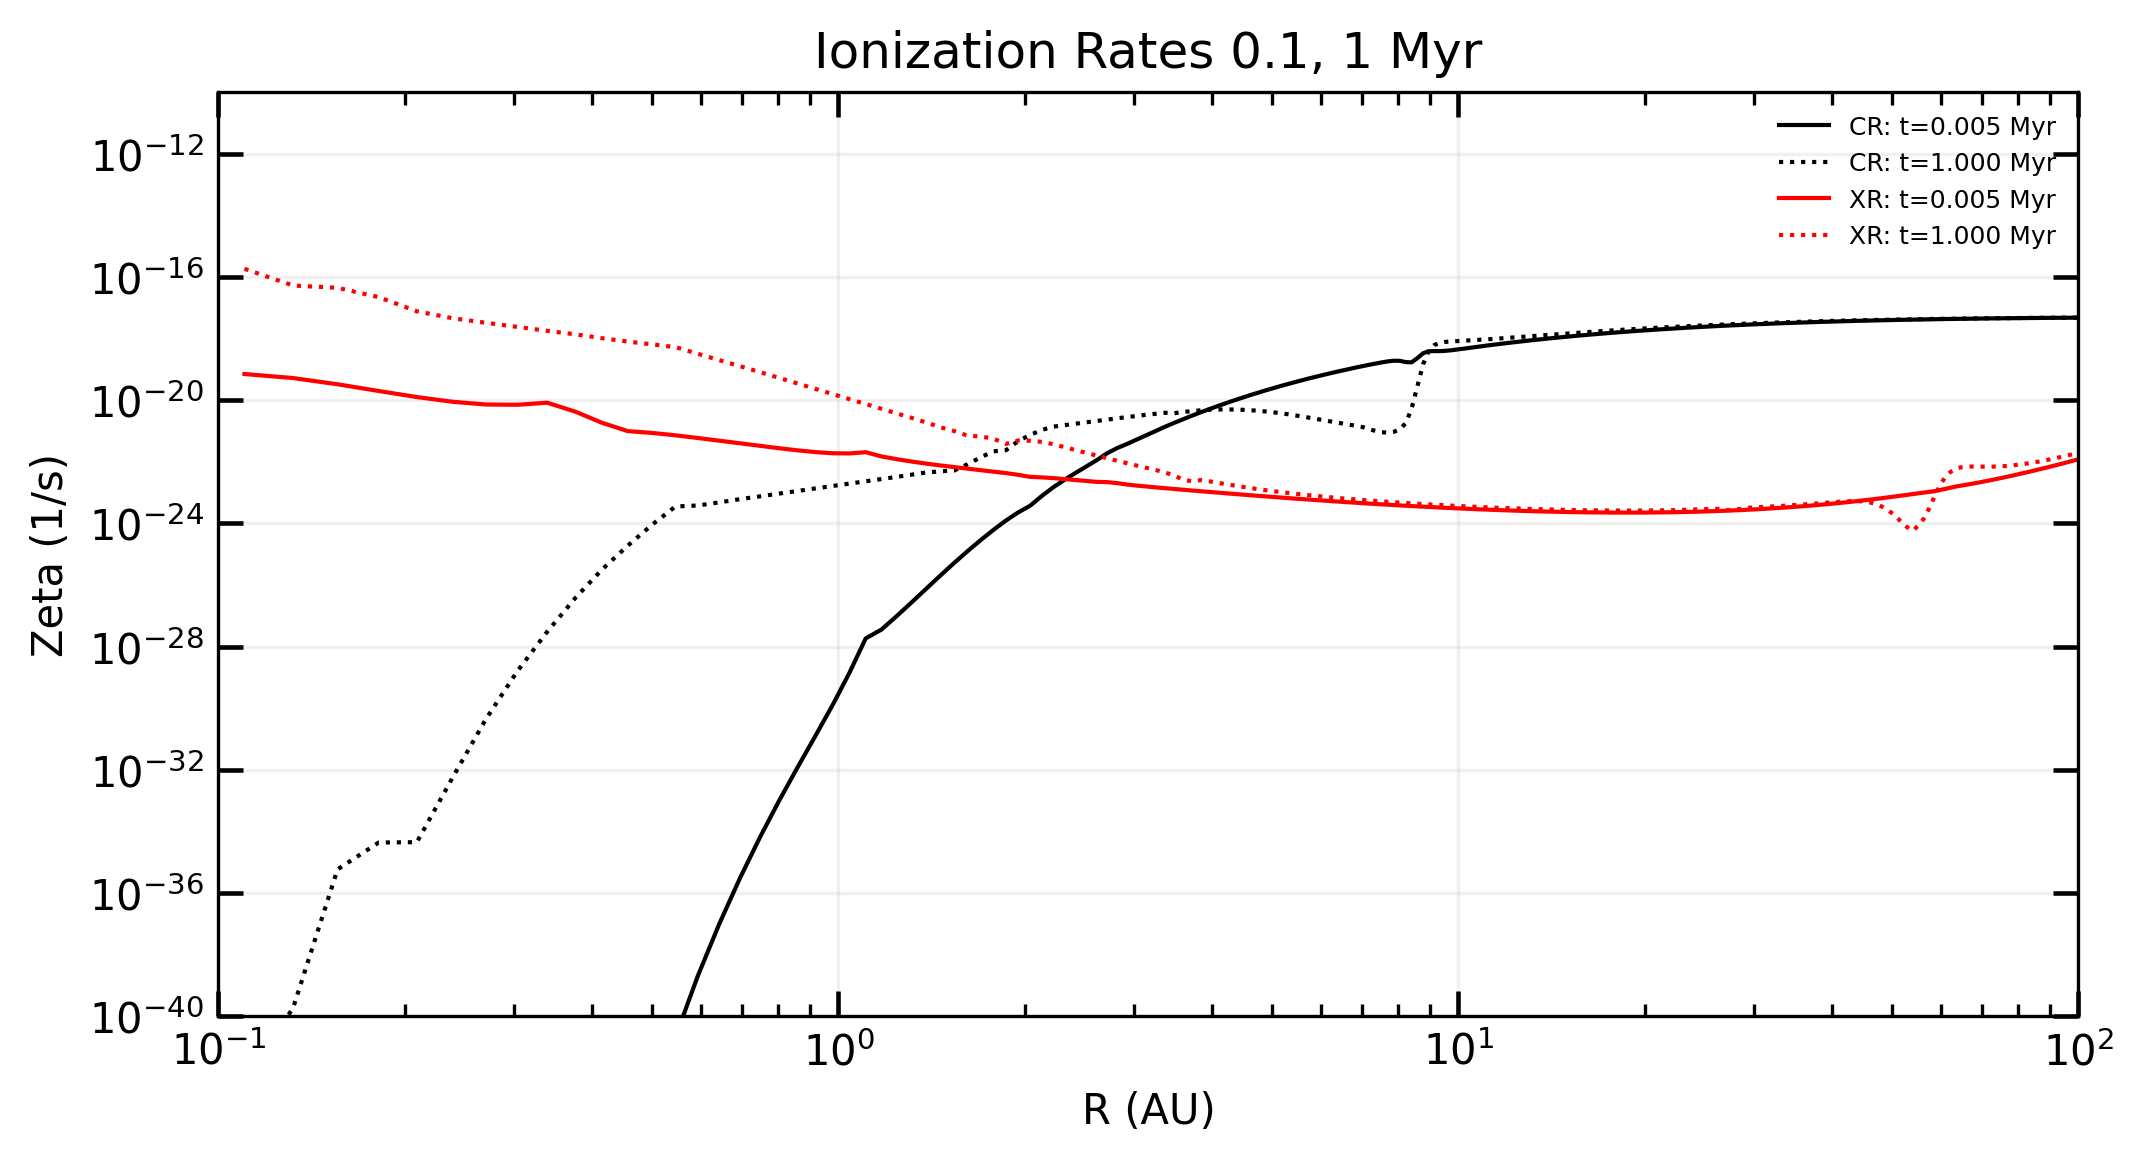

In [5]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('Ionization Rates 0.1, 1 Myr')
ax.set_xlim(0.1,100)
ax.set_ylim(1e-40,1e-10)

ax.loglog(crR, crZeta[cridx[1]], linestyle='solid', color='black', label=rf"CR: t={crt[cridx[1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crZeta[cridx[5]], linestyle='dotted', color='black', label=rf"CR: t={crt[cridx[5]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrZeta[xridx[1]], linestyle='solid', color='red', label=rf"XR: t={xrt[xridx[1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrZeta[xridx[5]], linestyle='dotted', color='red', label=rf"XR: t={xrt[xridx[5]]/1e6:.3f} Myr", lw = 1.0)
# ax.loglog(cxR, cxZeta[cxidx[1]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[1]]/1e6:.3f} Myr", lw = 1.0)
# ax.loglog(cxR, cxZeta[cxidx[5]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[5]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

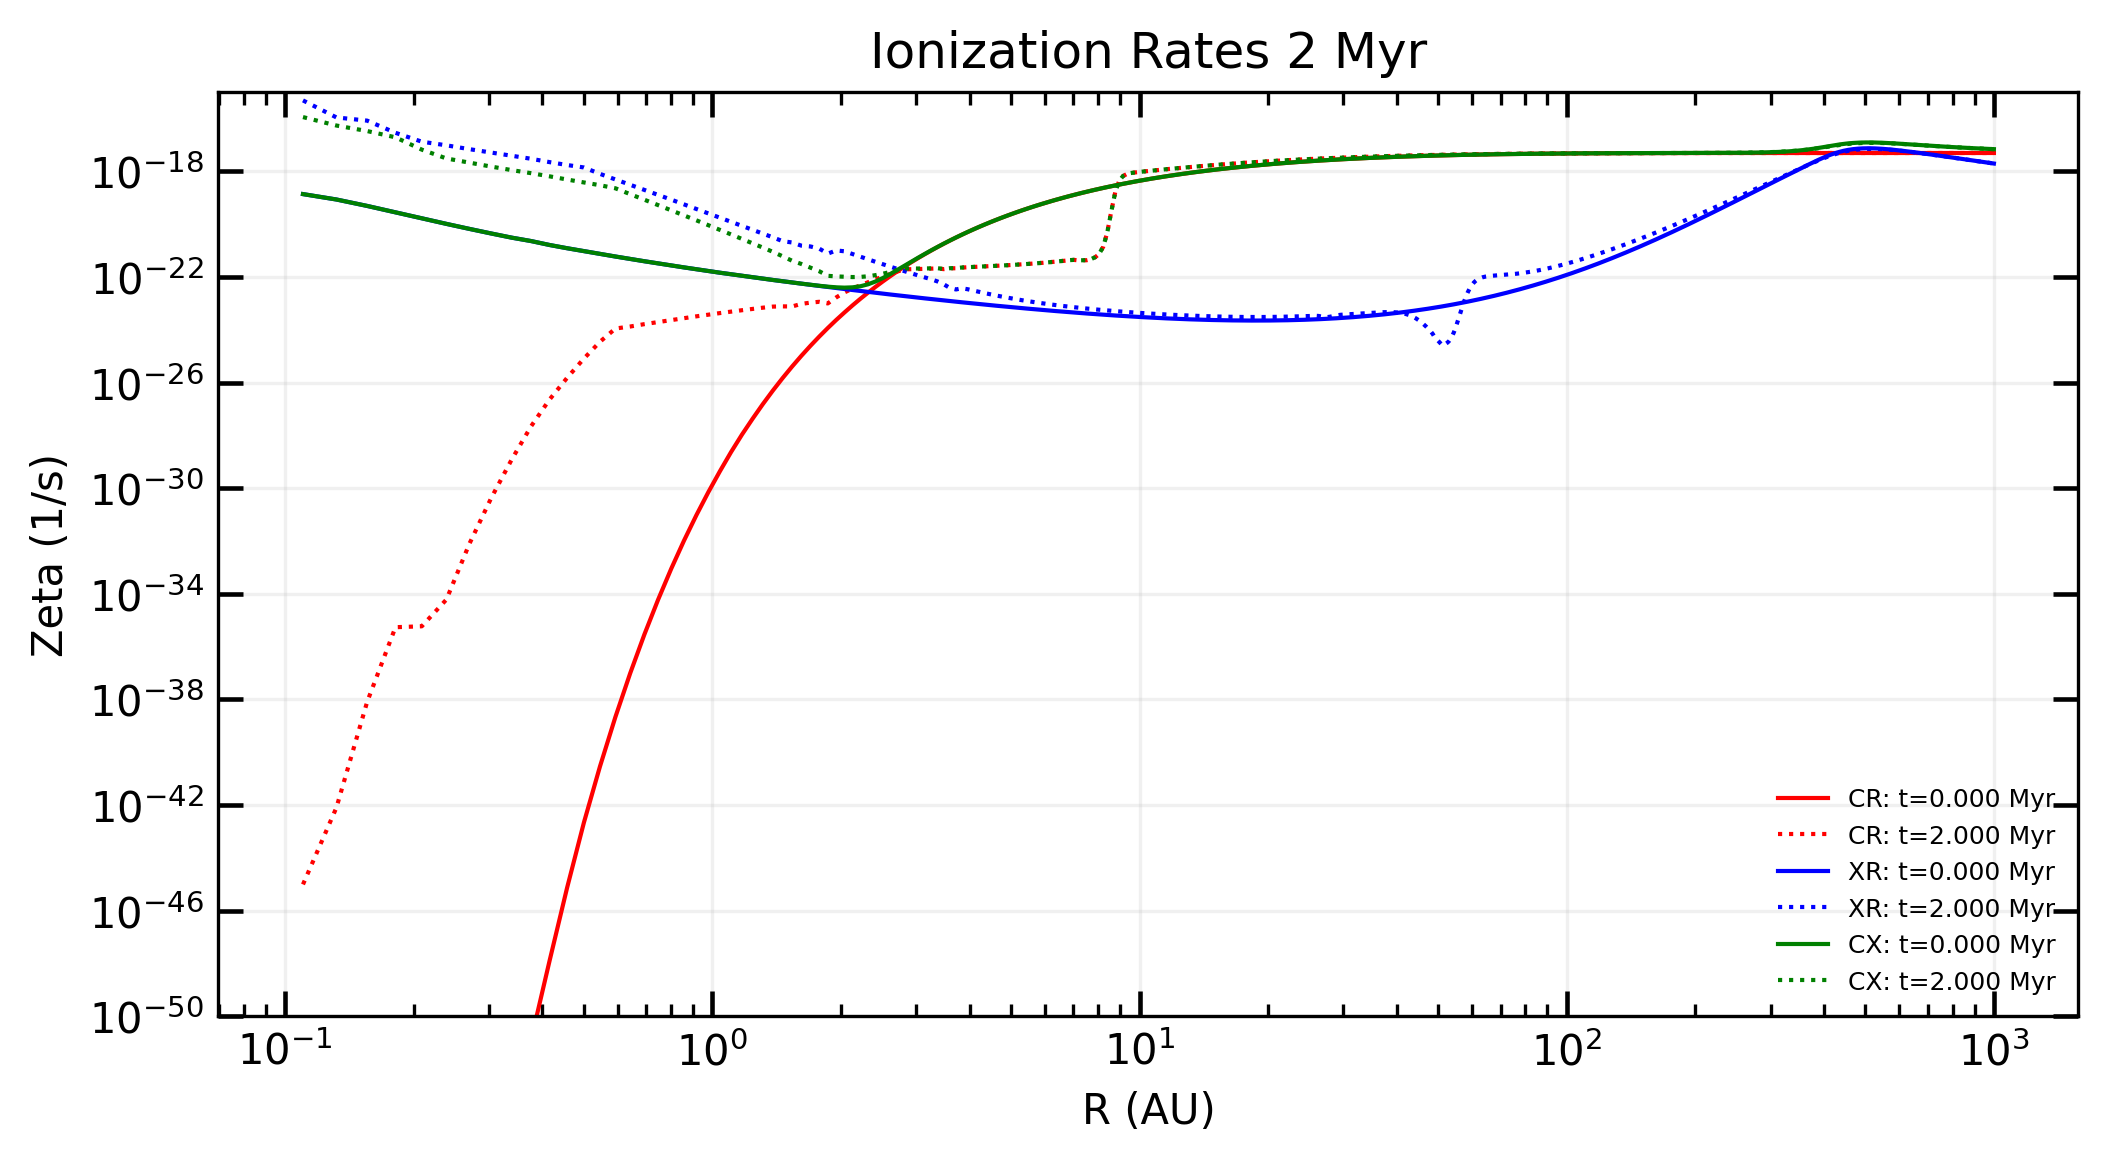

In [6]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('Ionization Rates 2 Myr')
#ax.set_xlim(8,10)
ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, crZeta[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crZeta[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrZeta[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrZeta[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZeta[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxZeta[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

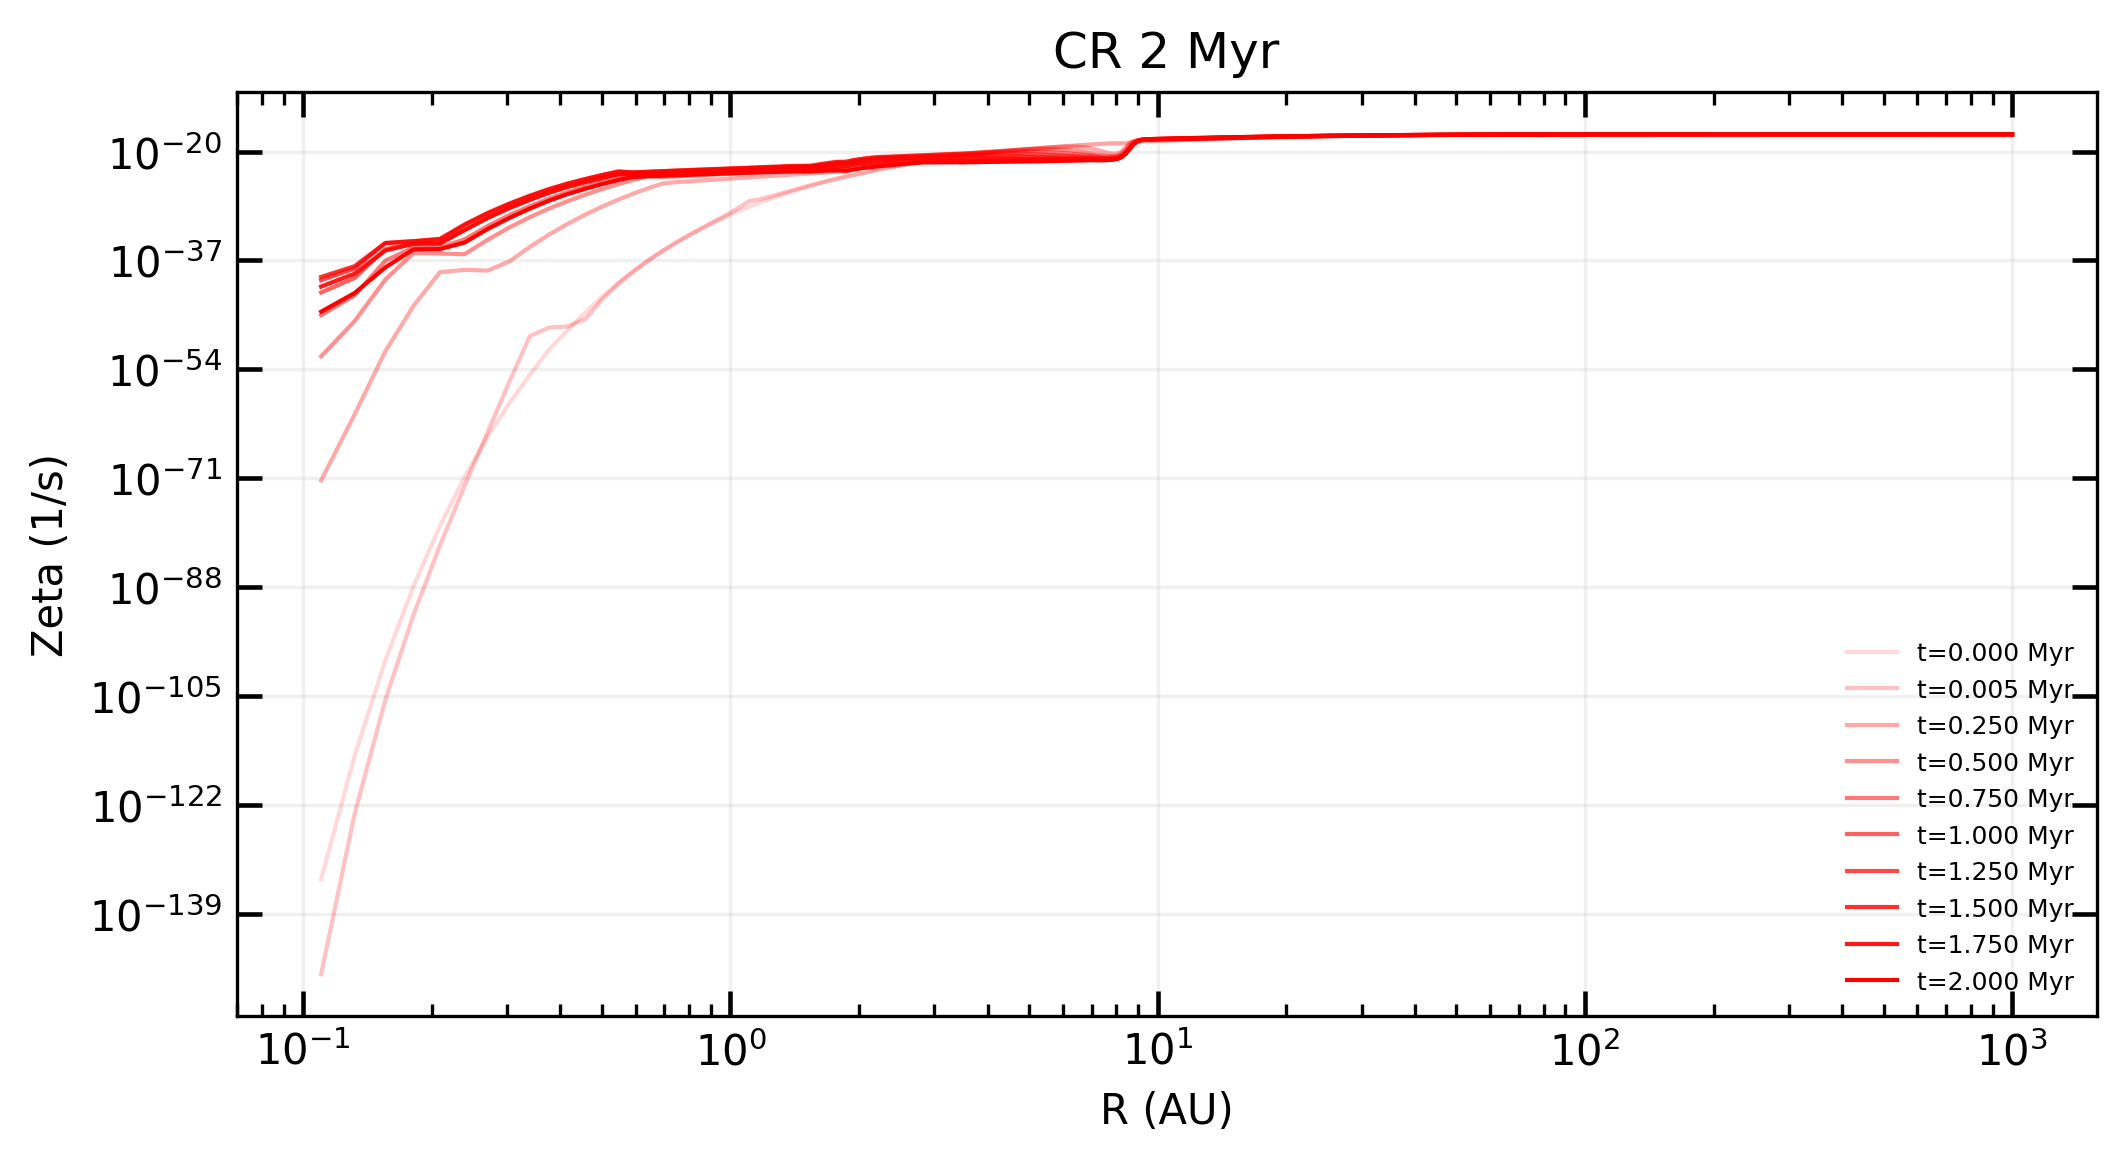

In [7]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR
ydata = crZeta
for a_i, i in enumerate(cridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

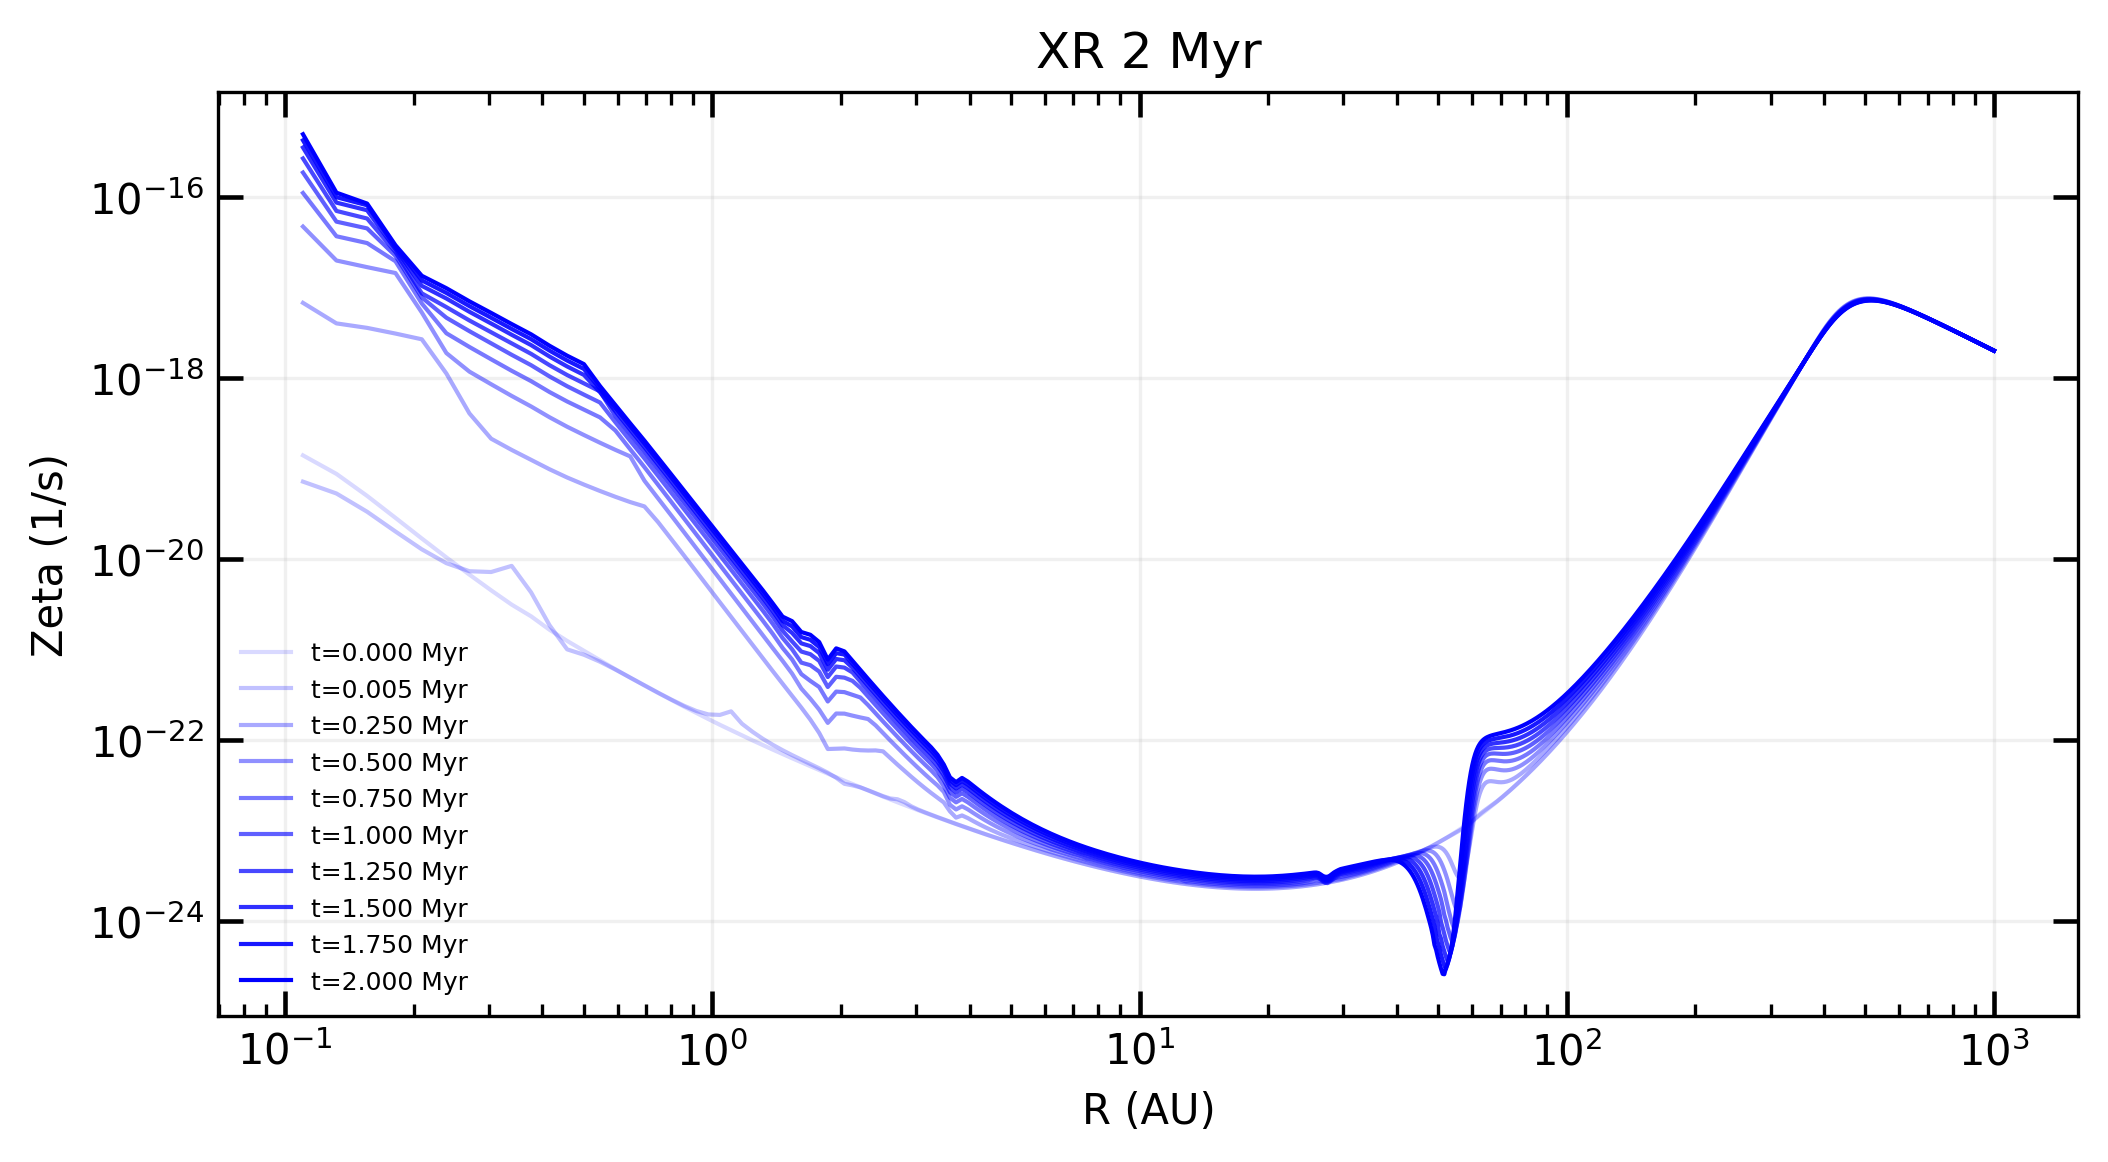

In [8]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('XR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrZeta
for a_i, i in enumerate(xridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

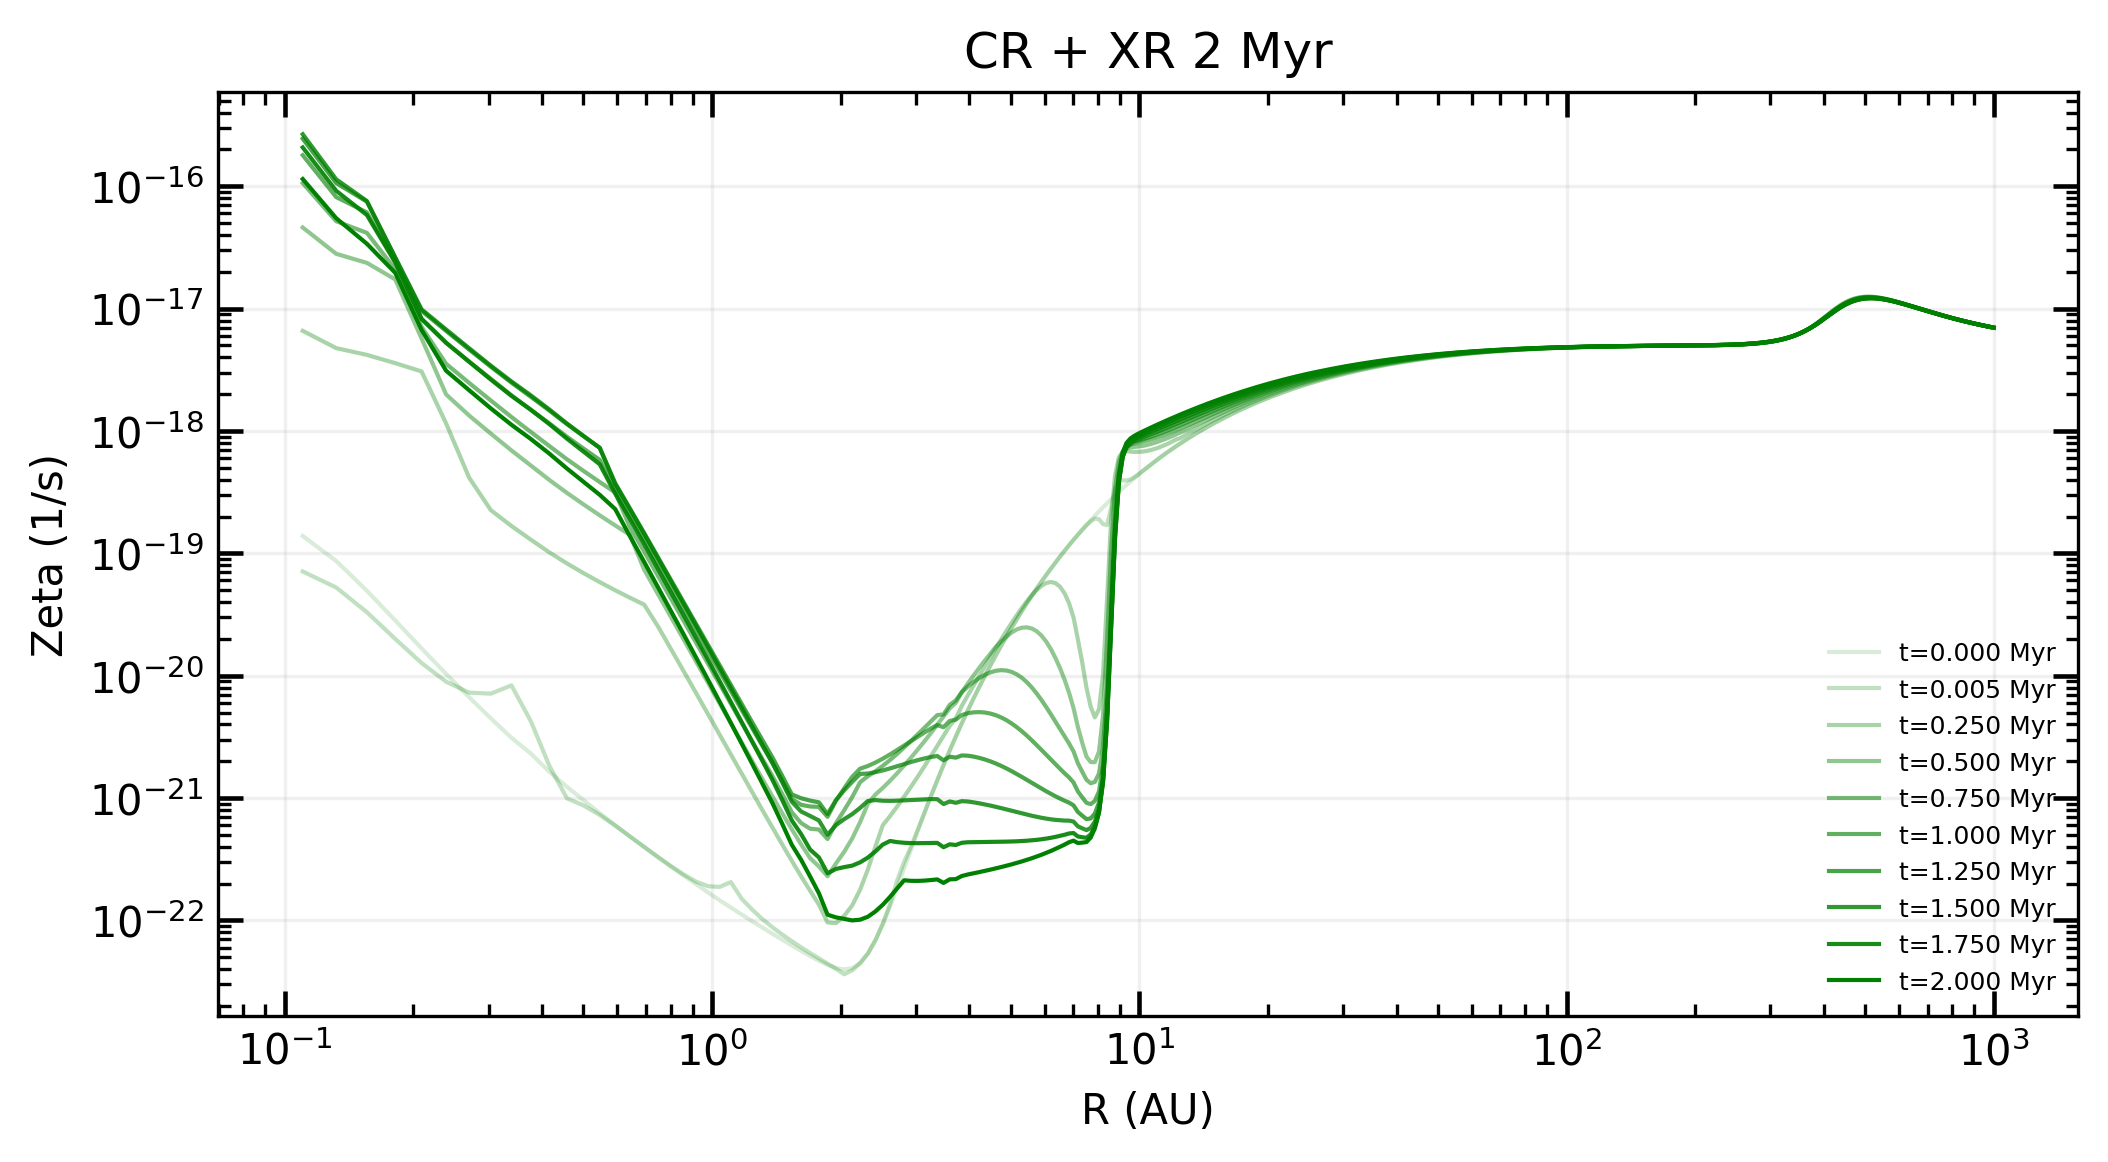

In [9]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Zeta (1/s)')
plt.title('CR + XR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxZeta
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Deadzone Radius

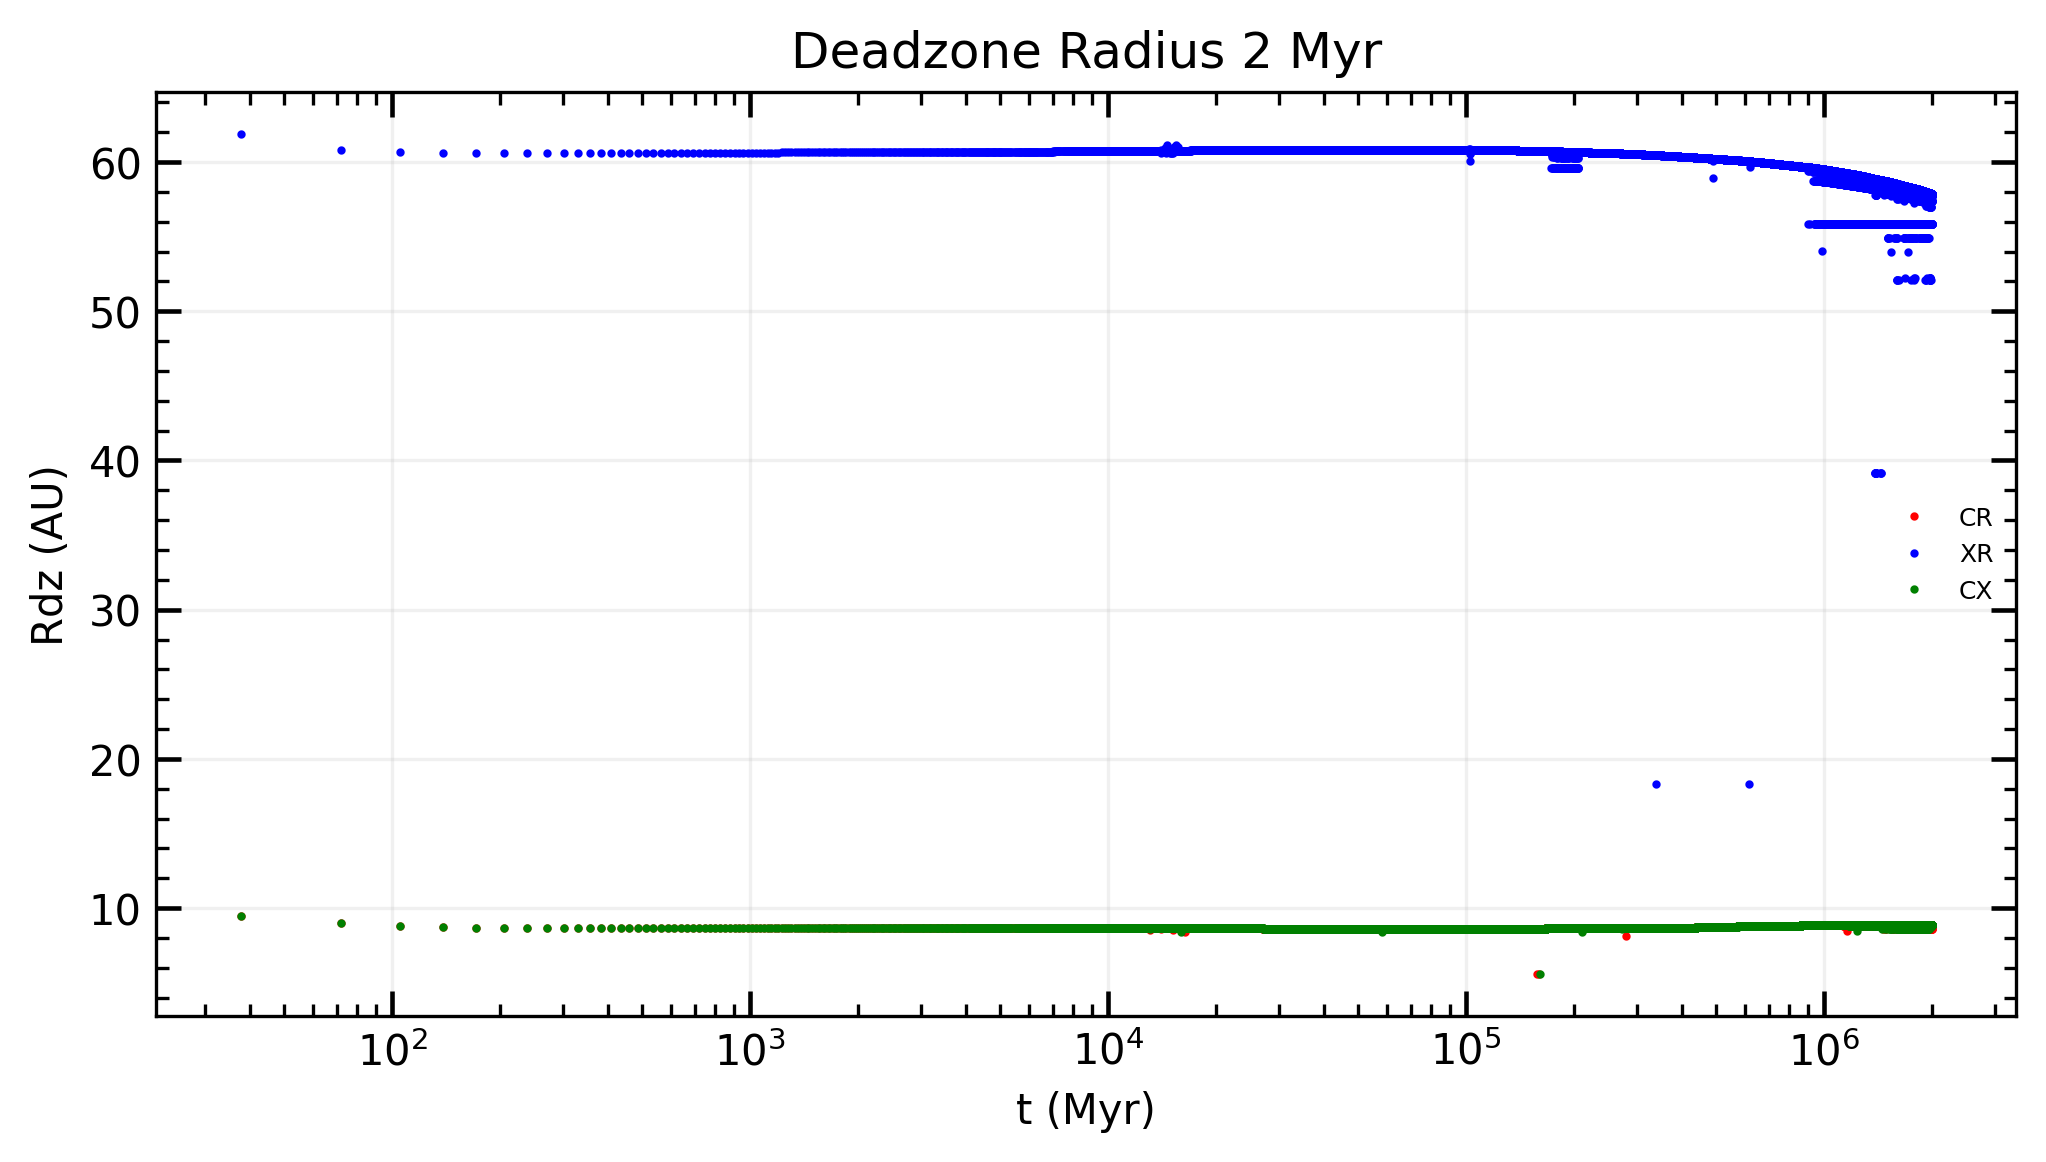

In [10]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
plt.title('Deadzone Radius 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.semilogx(crt, crRdz, '.r', label=rf"CR", ms = 2.0)
ax.semilogx(xrt, xrRdz, '.b', label=rf"XR", ms = 2.0)
ax.semilogx(cxt, cxRdz, '.g', label=rf"CX", ms = 2.0)

ax.legend(frameon=False, fontsize=6, loc="best")

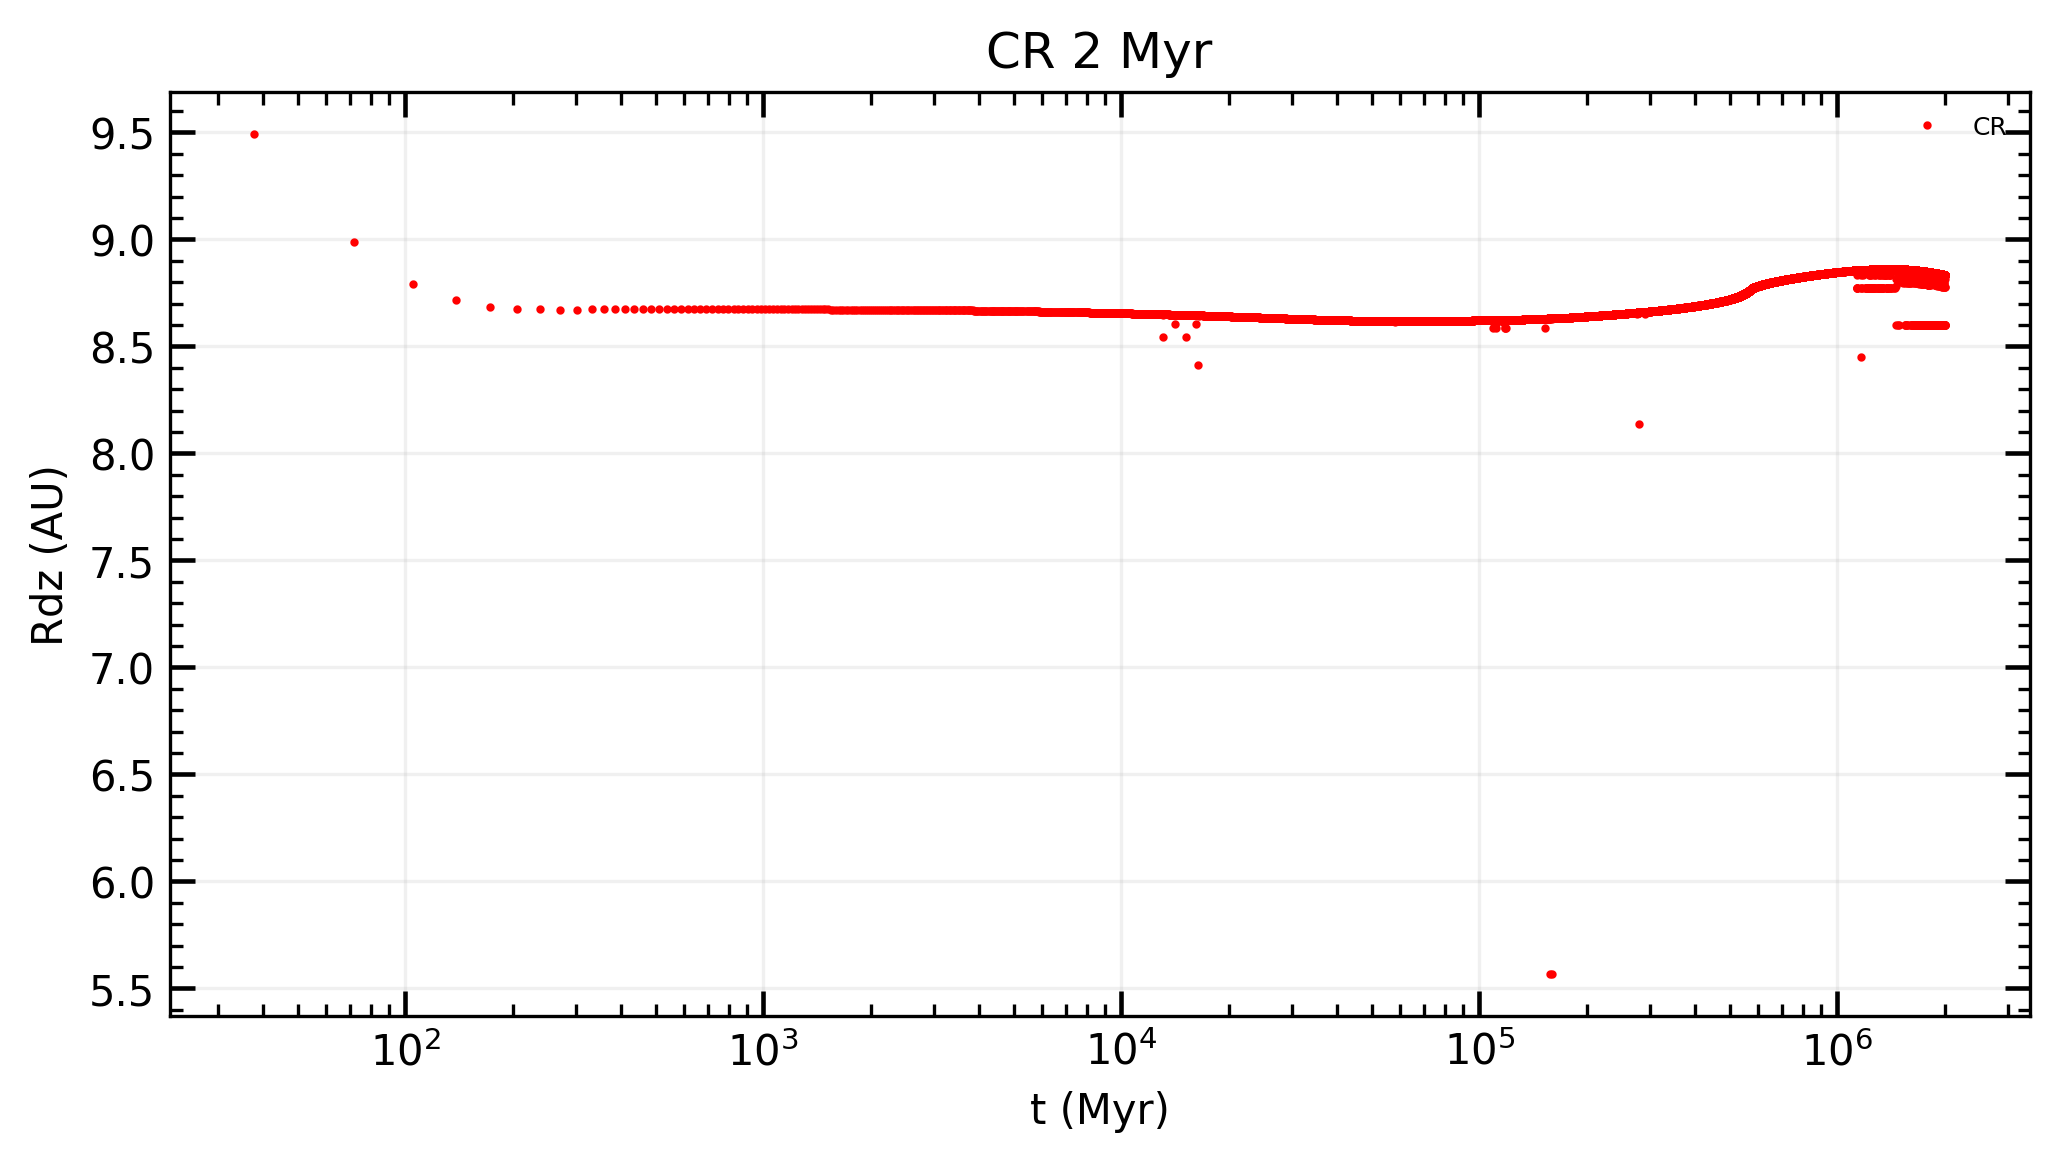

In [11]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
plt.title('CR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.semilogx(crt, crRdz, '.r', label=rf"CR", ms = 2.0)

ax.legend(frameon=False, fontsize=6, loc="best")

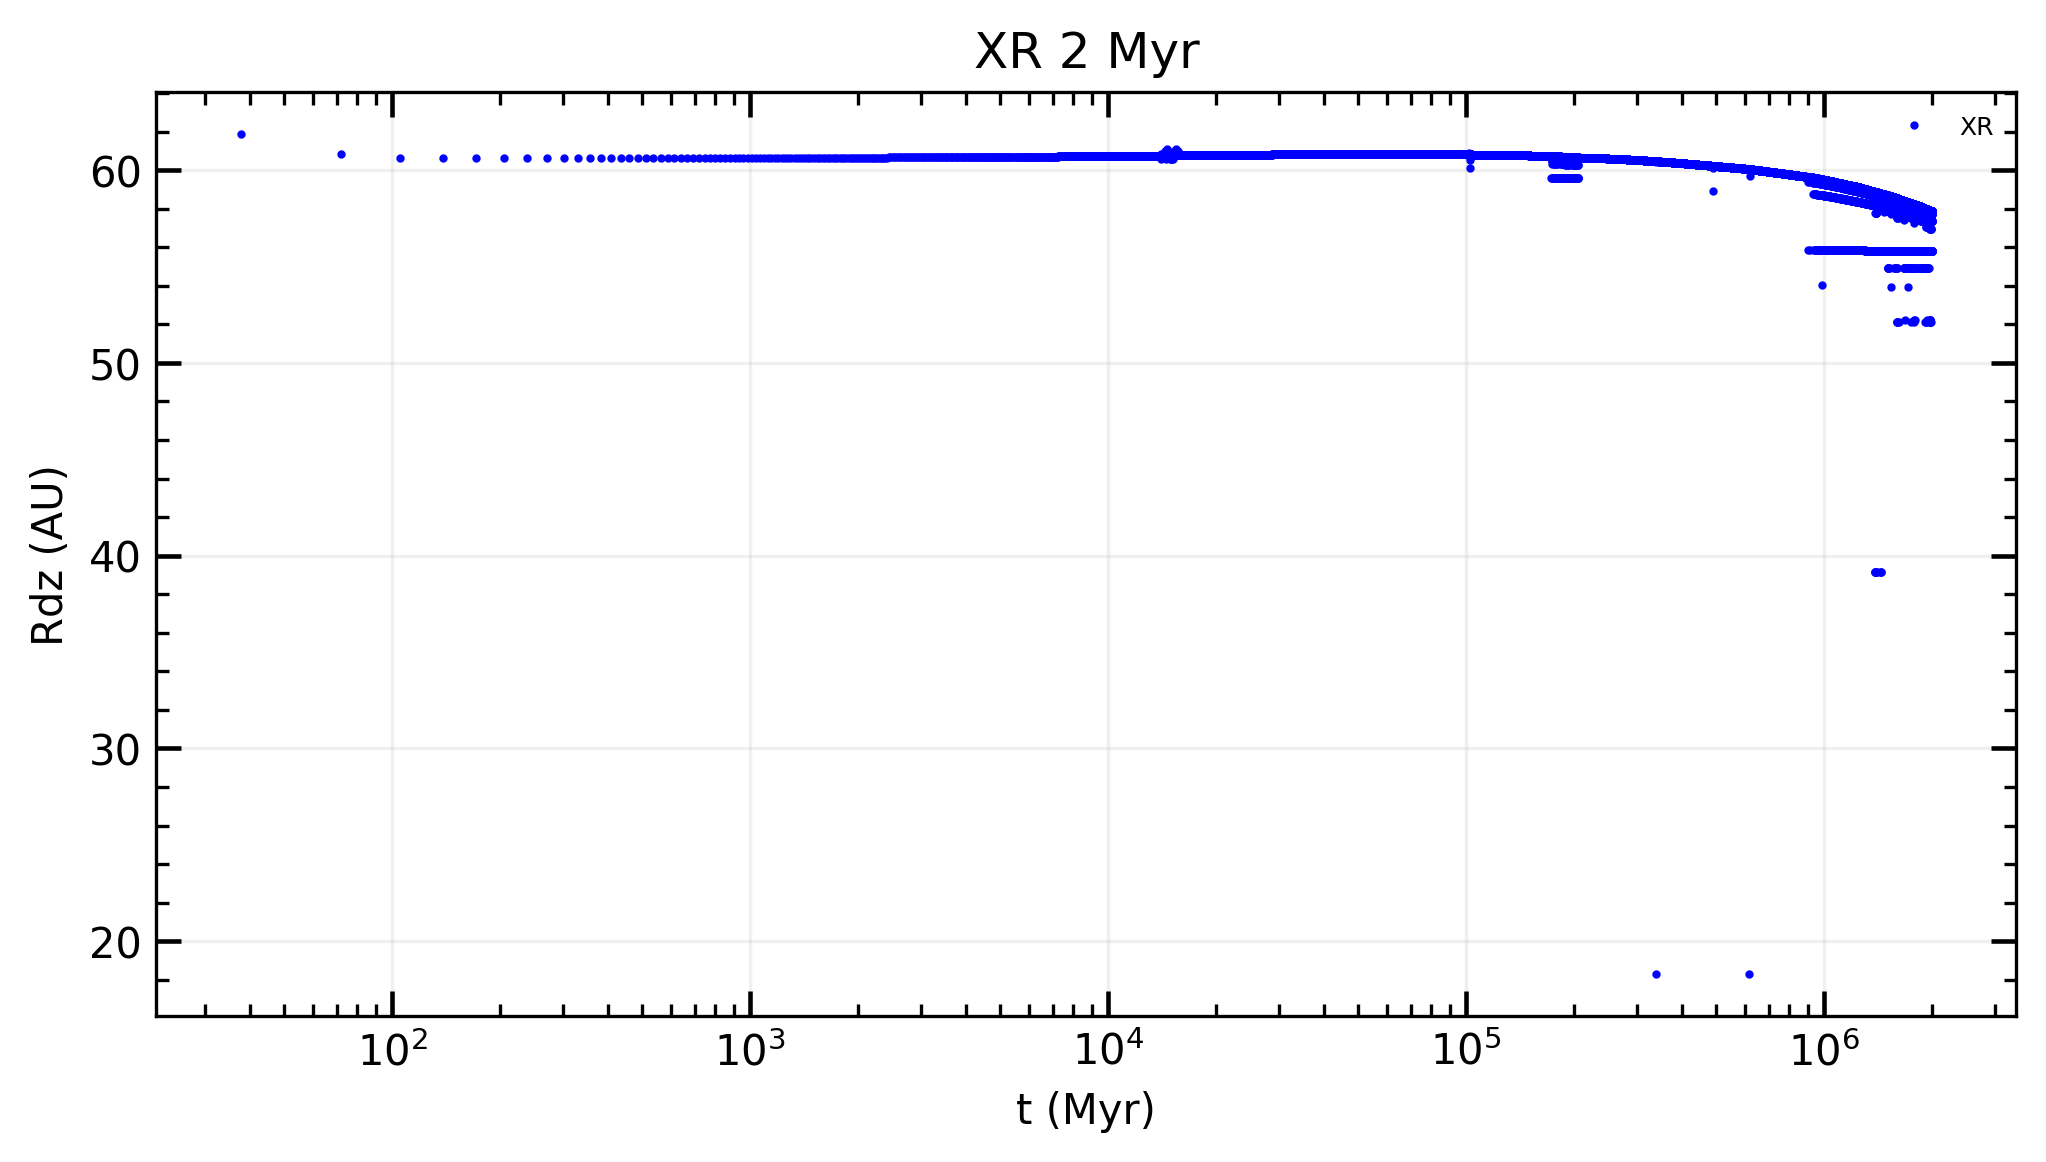

In [12]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
plt.title('XR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.semilogx(xrt, xrRdz, '.b', label=rf"XR", ms = 2.0)

ax.legend(frameon=False, fontsize=6, loc="best")

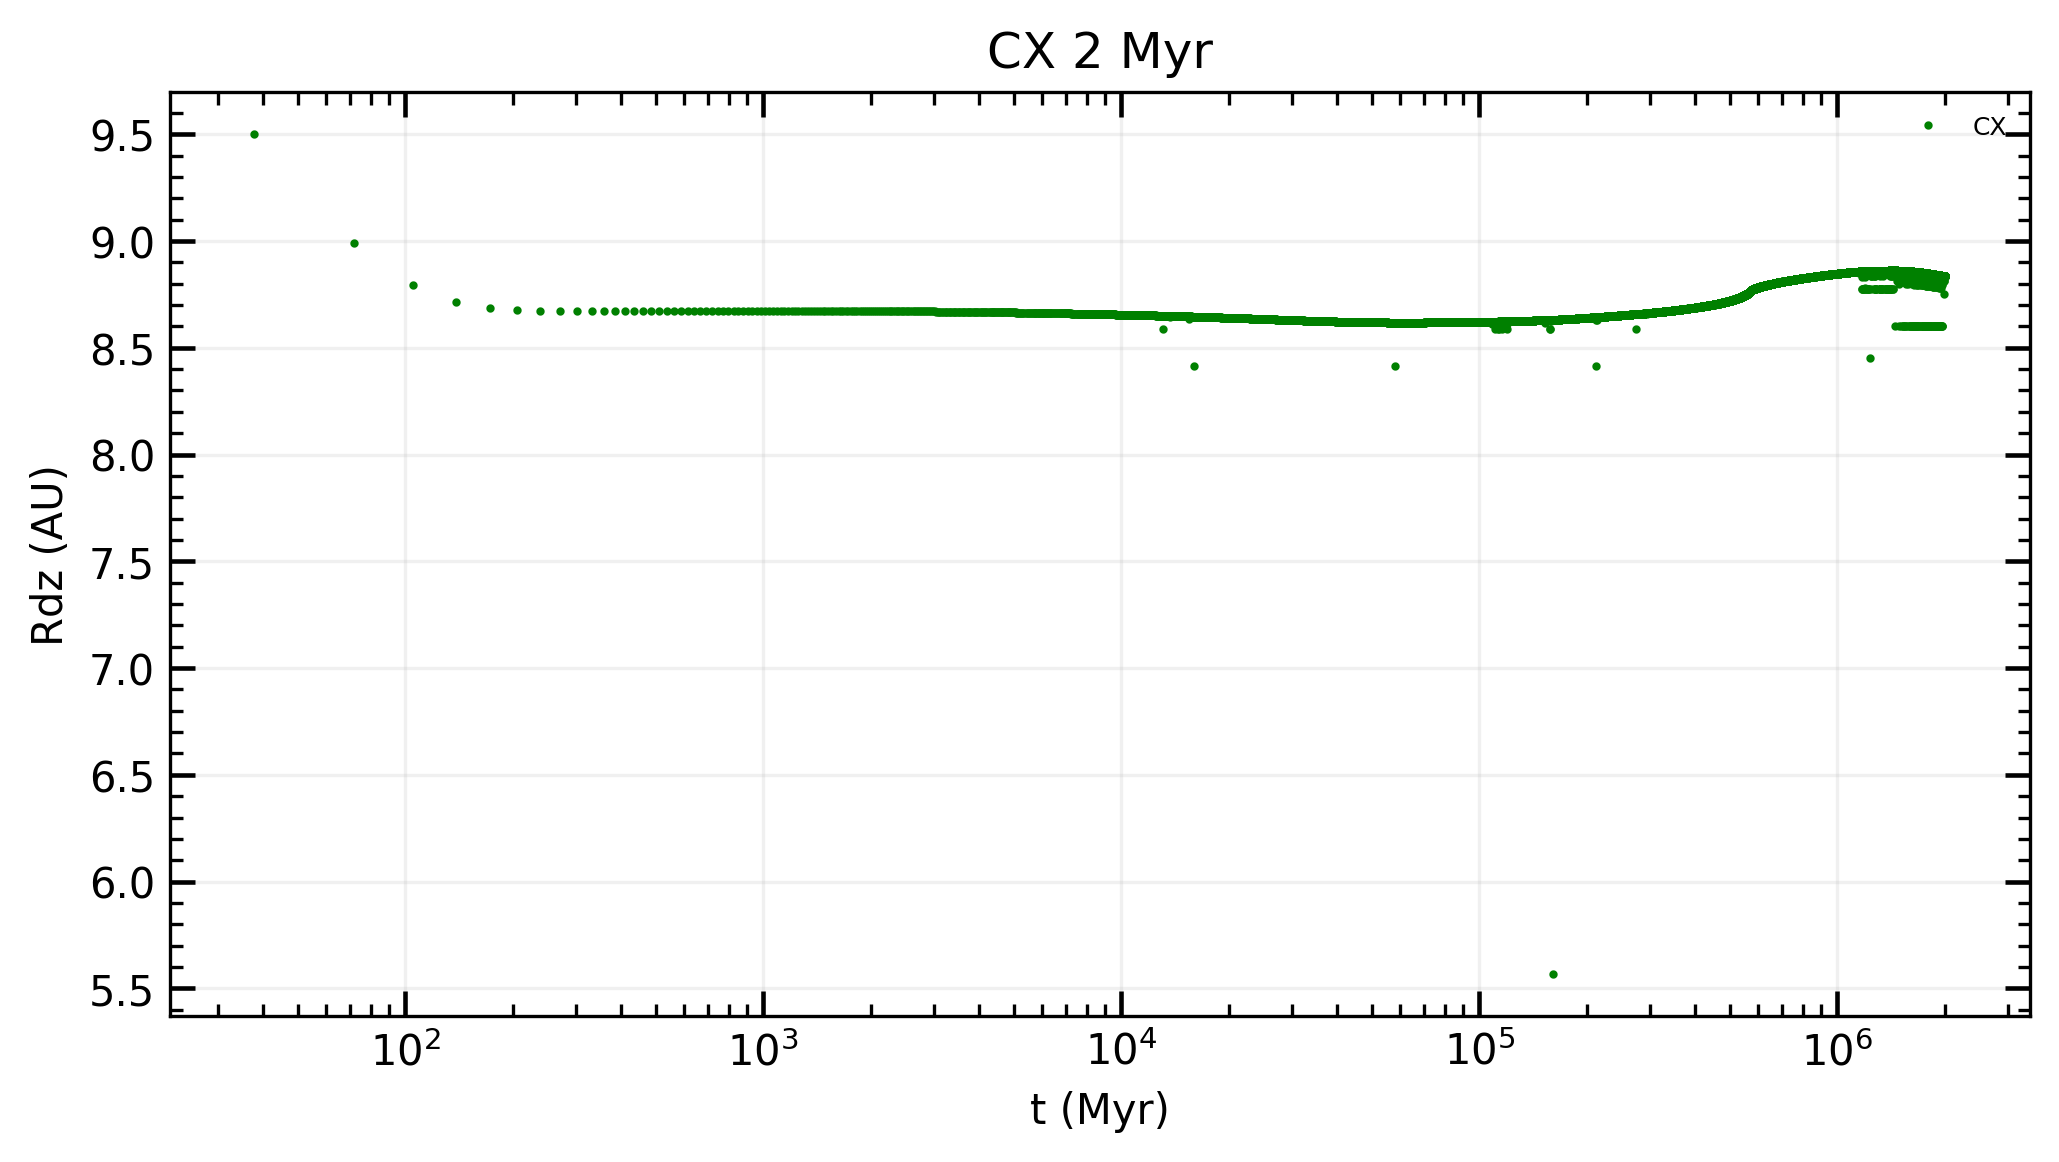

In [13]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('t (Myr)')
ax.set_ylabel('Rdz (AU)')
plt.title('CX 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.semilogx(cxt, cxRdz, '.g', label=rf"CX", ms = 2.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# xe electron fraction

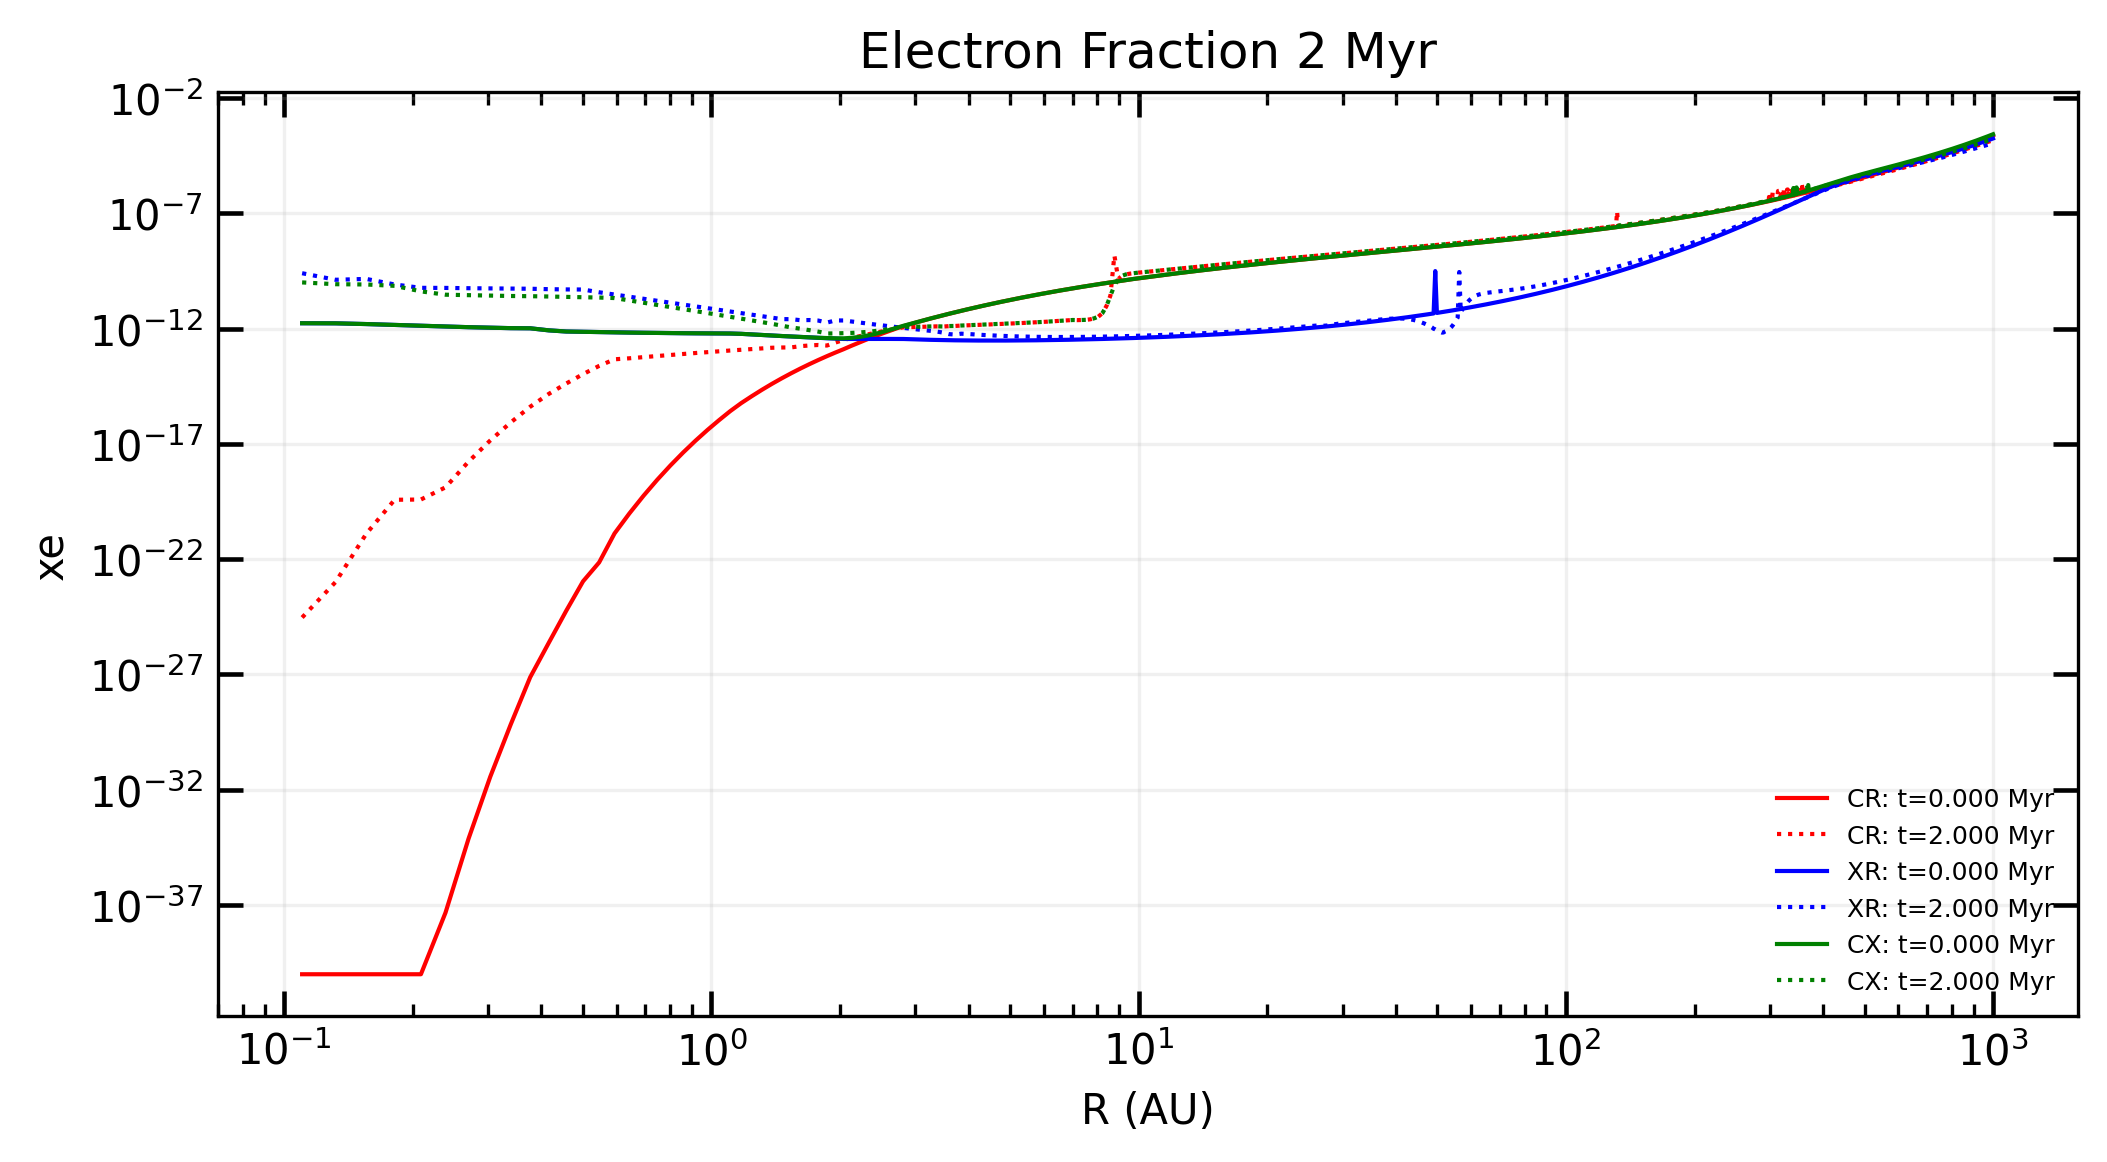

In [14]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
plt.title('Electron Fraction 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, crxe[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crxe[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrxe[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrxe[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxxe[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxxe[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

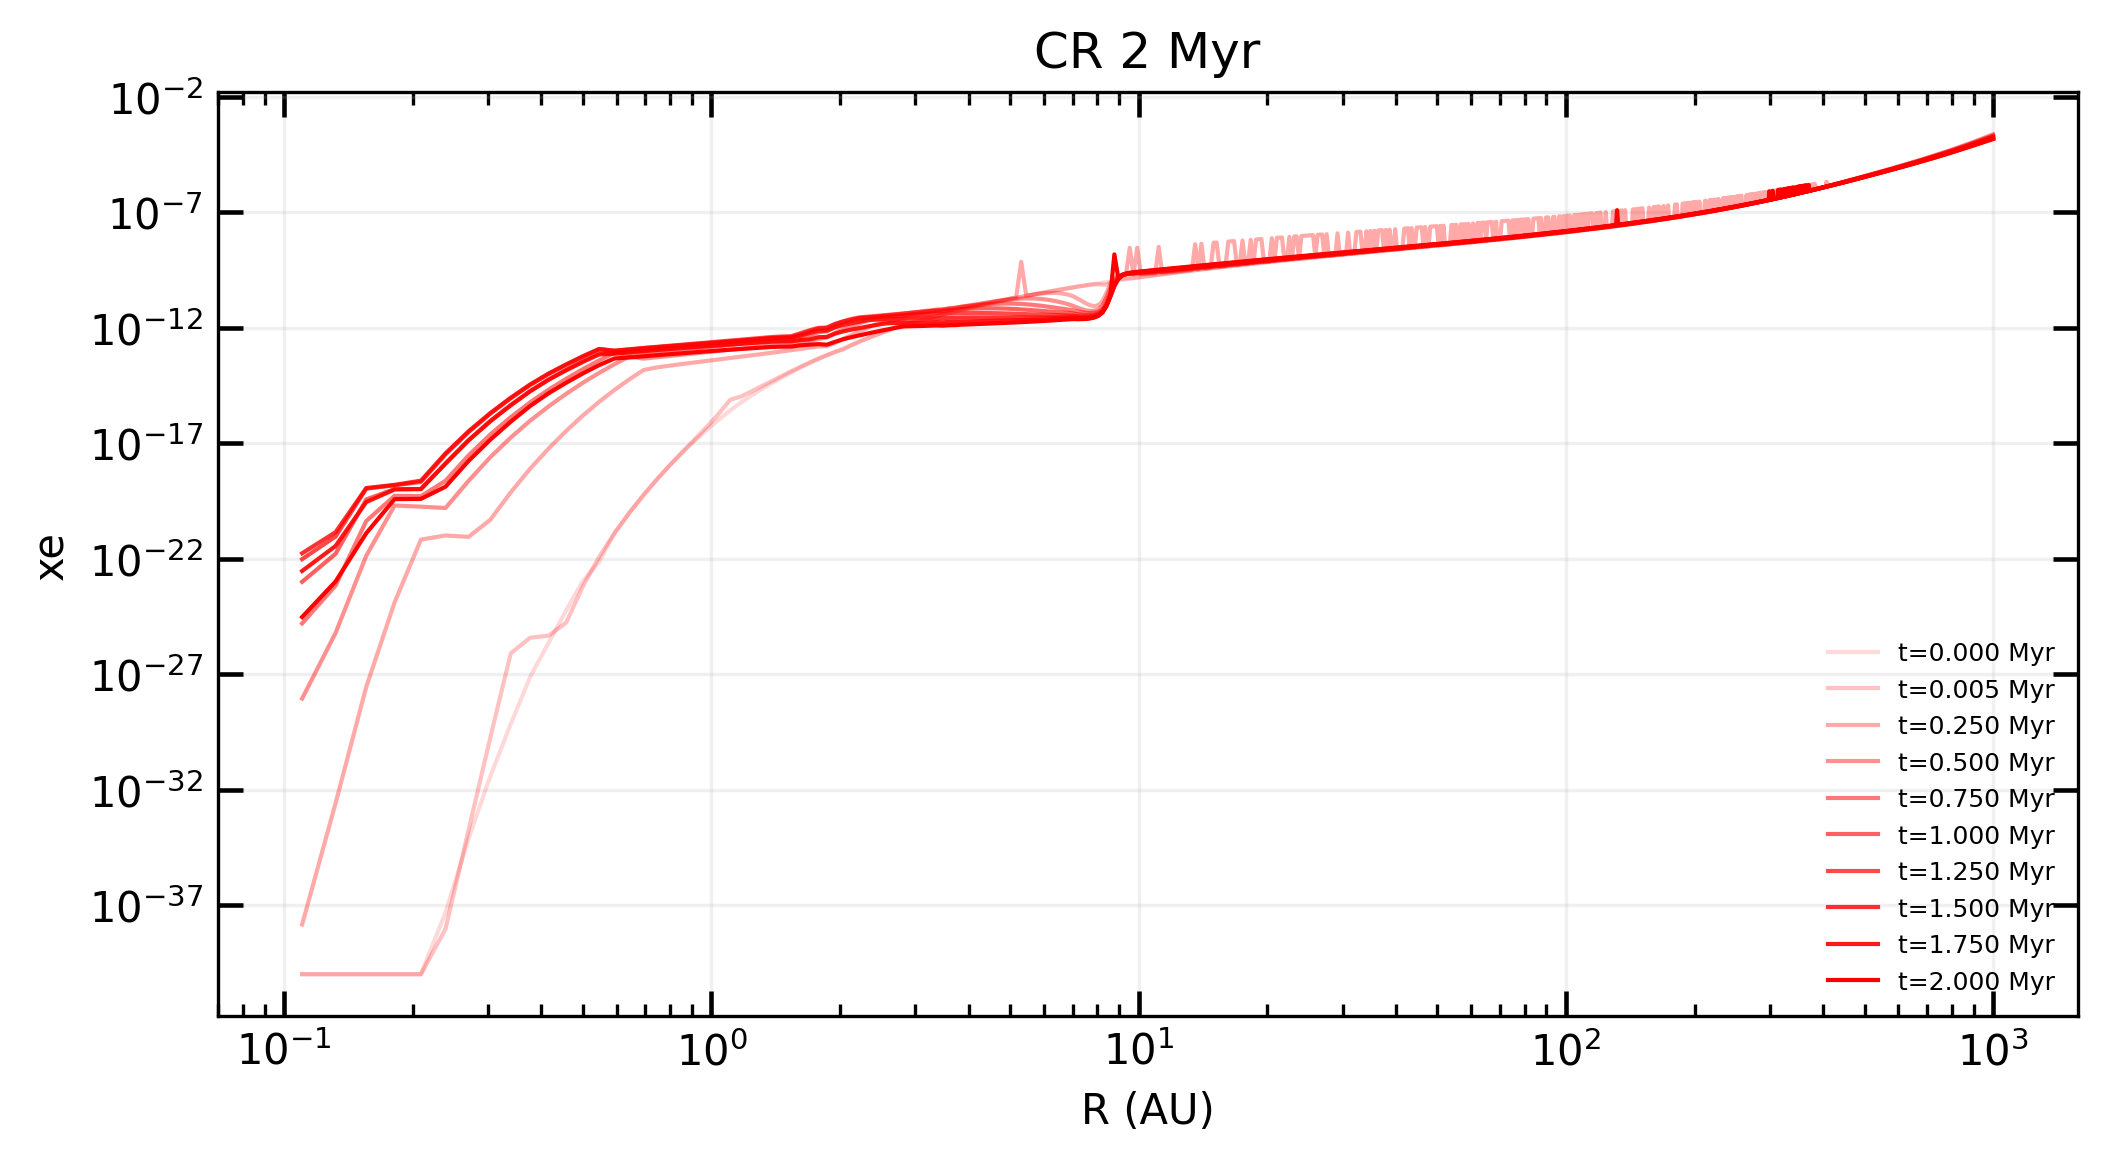

In [15]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
plt.title('CR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR
ydata = crxe
for a_i, i in enumerate(cridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

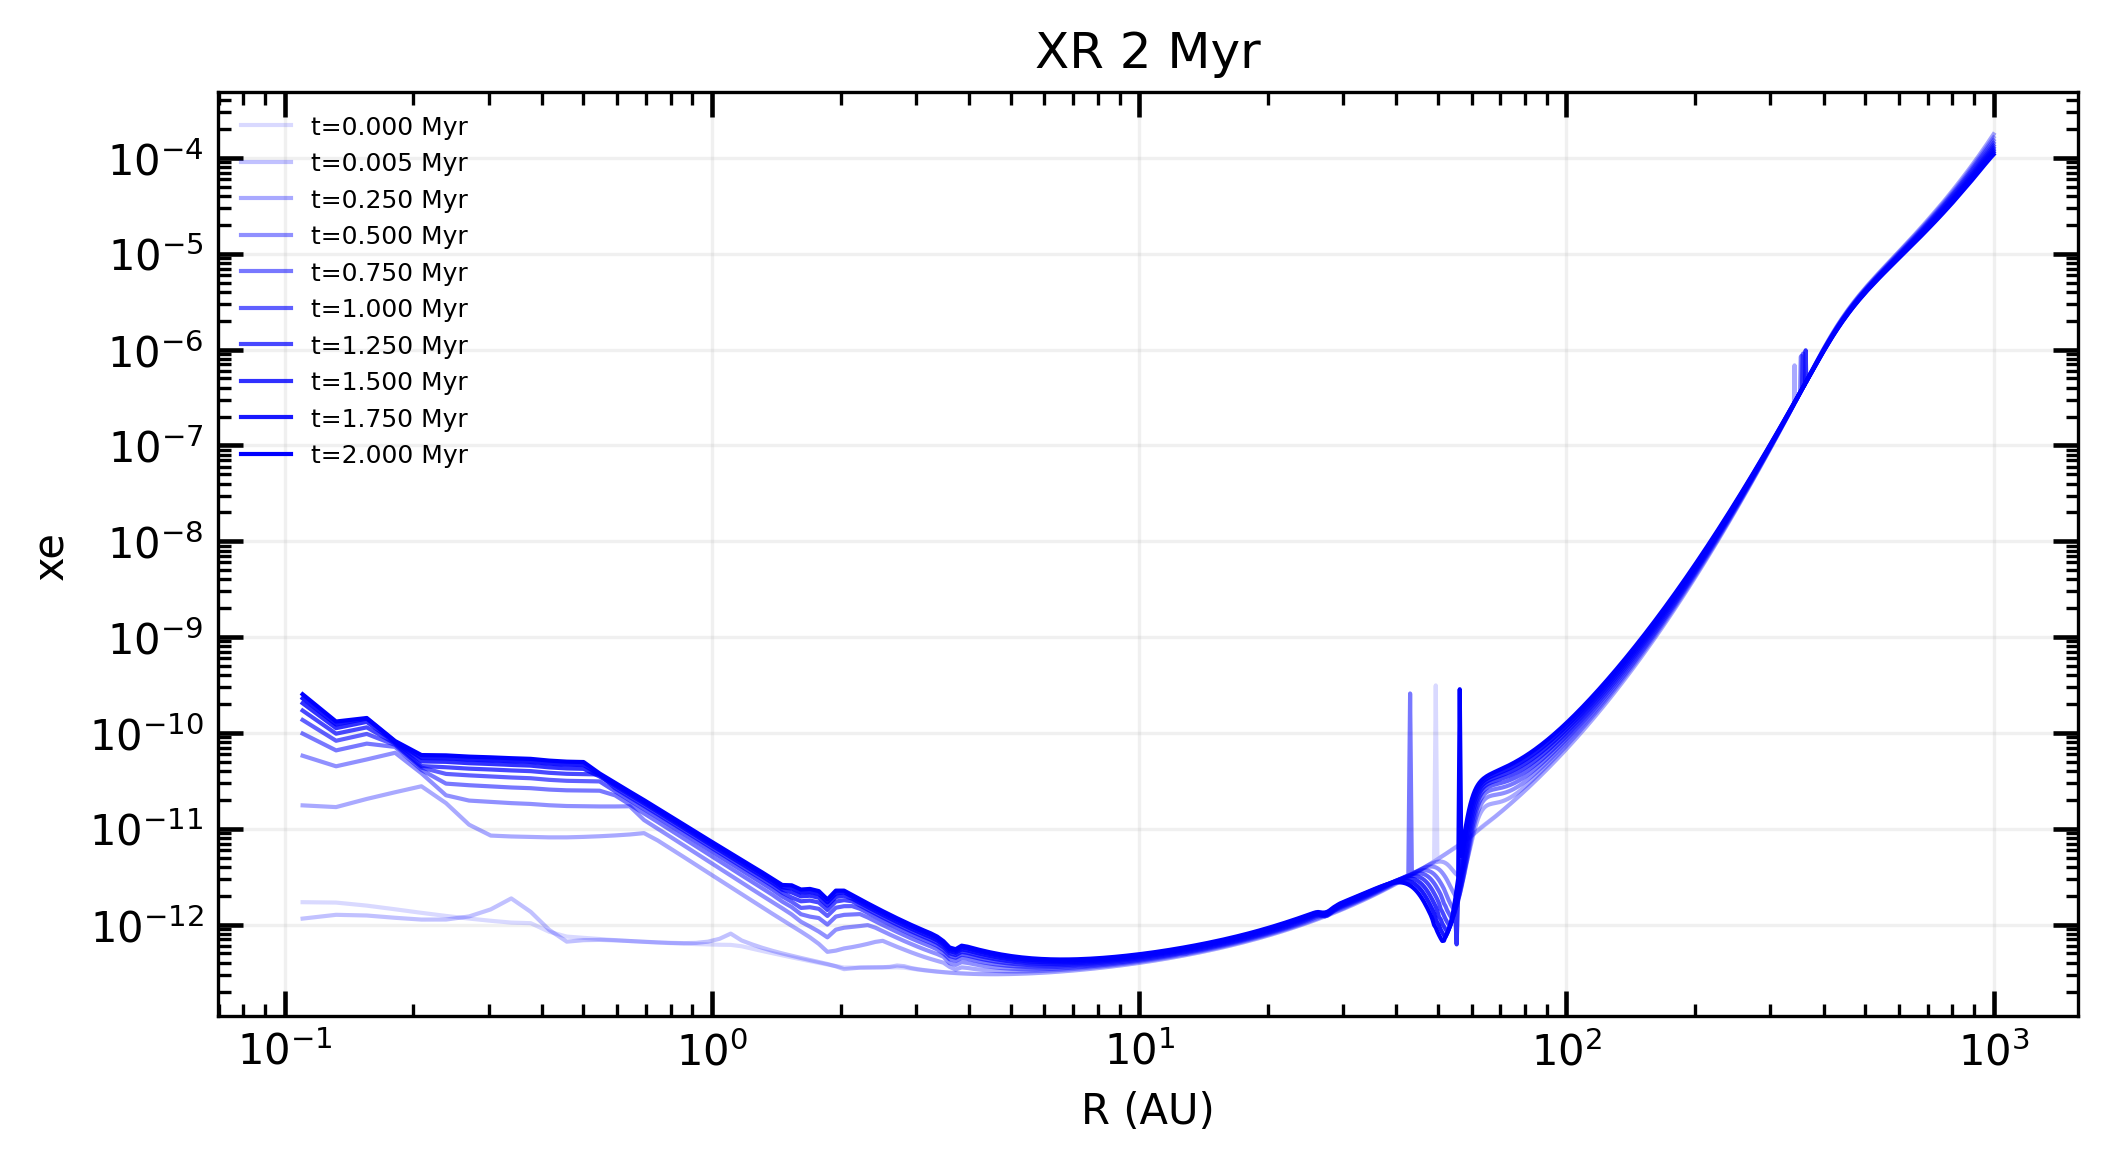

In [16]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
plt.title('XR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrxe
for a_i, i in enumerate(xridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

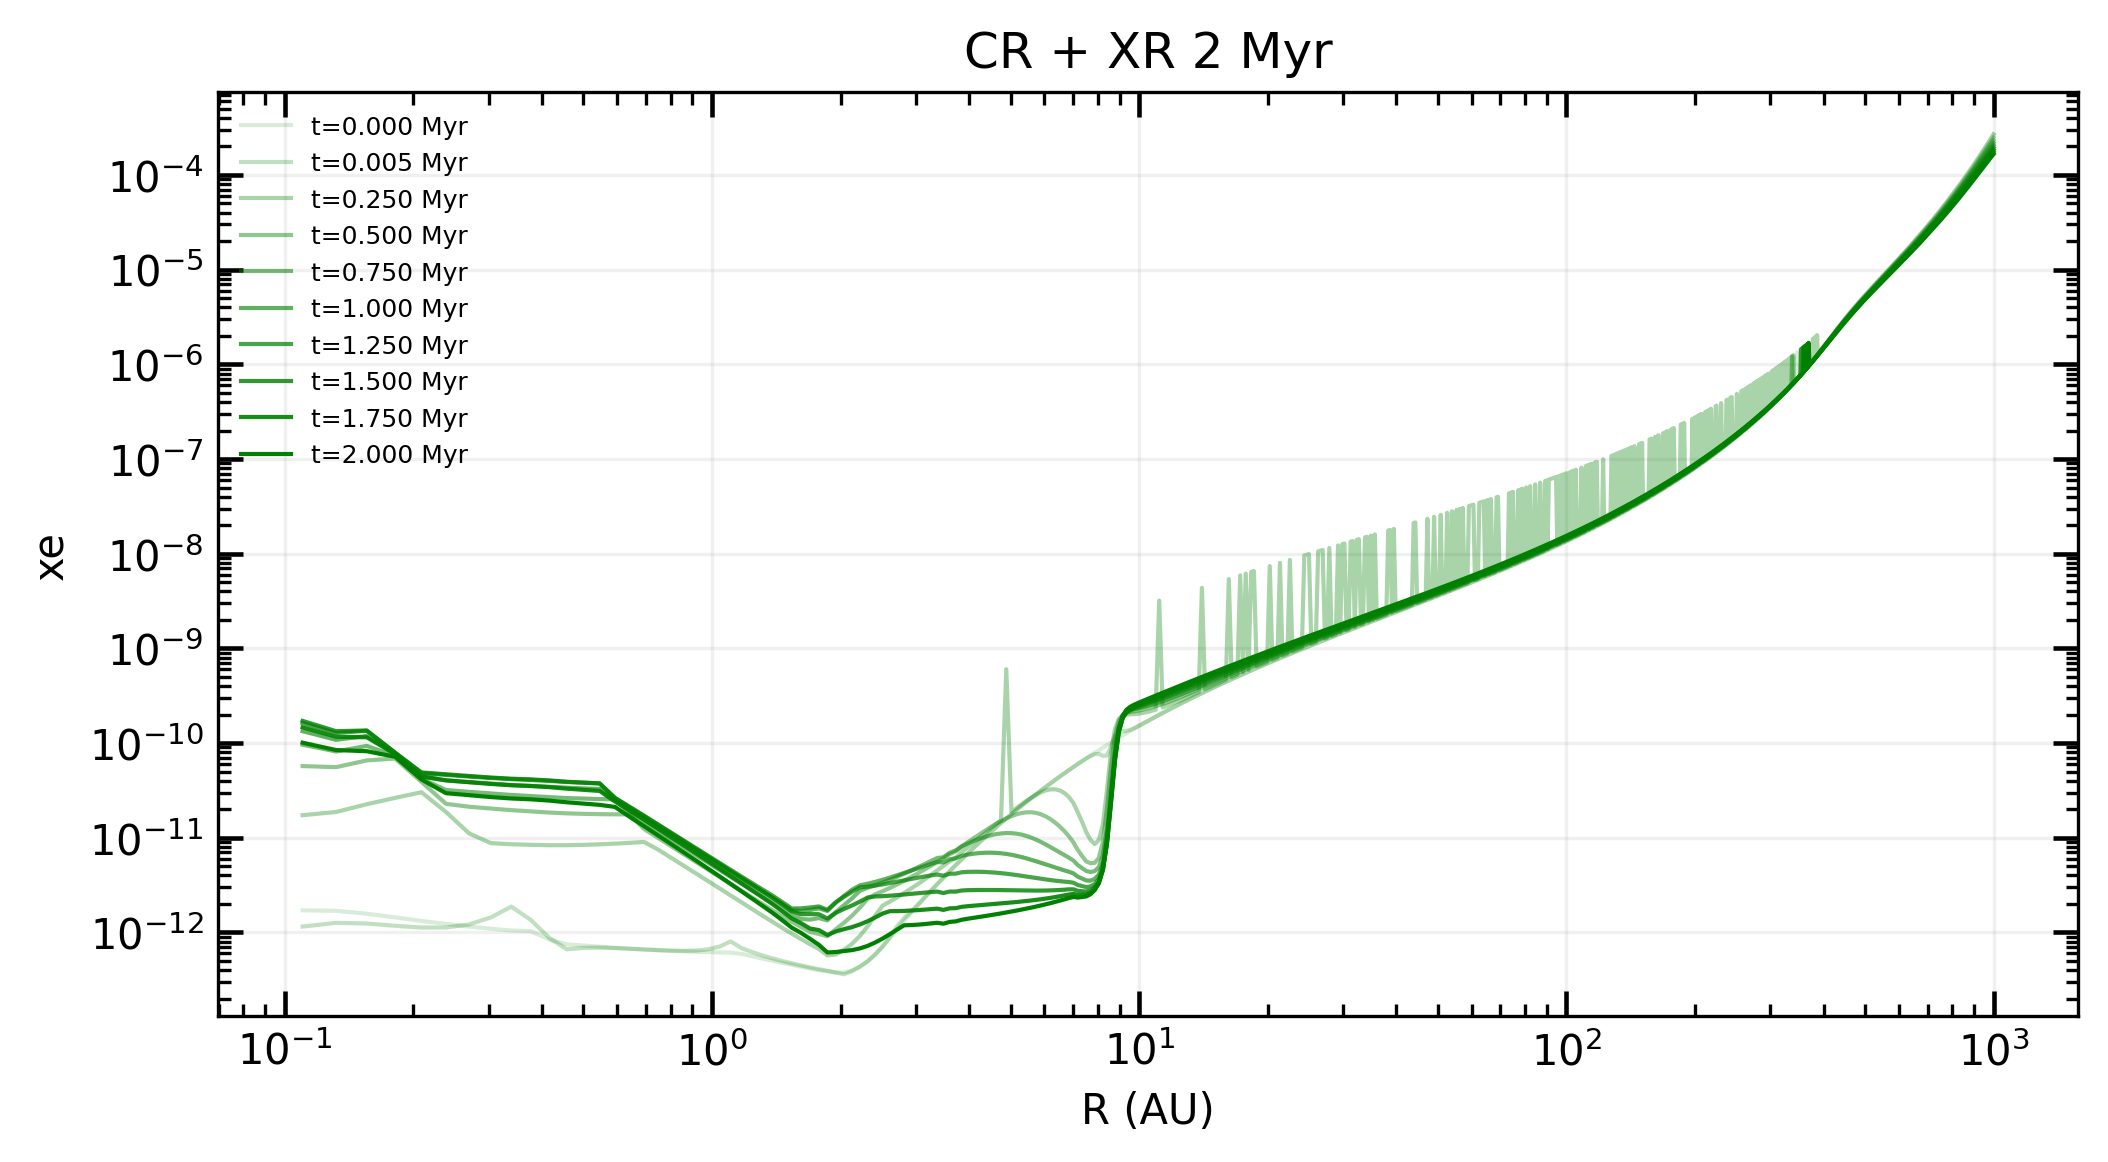

In [17]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('xe')
plt.title('CR + XR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxxe
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Elsasser Number

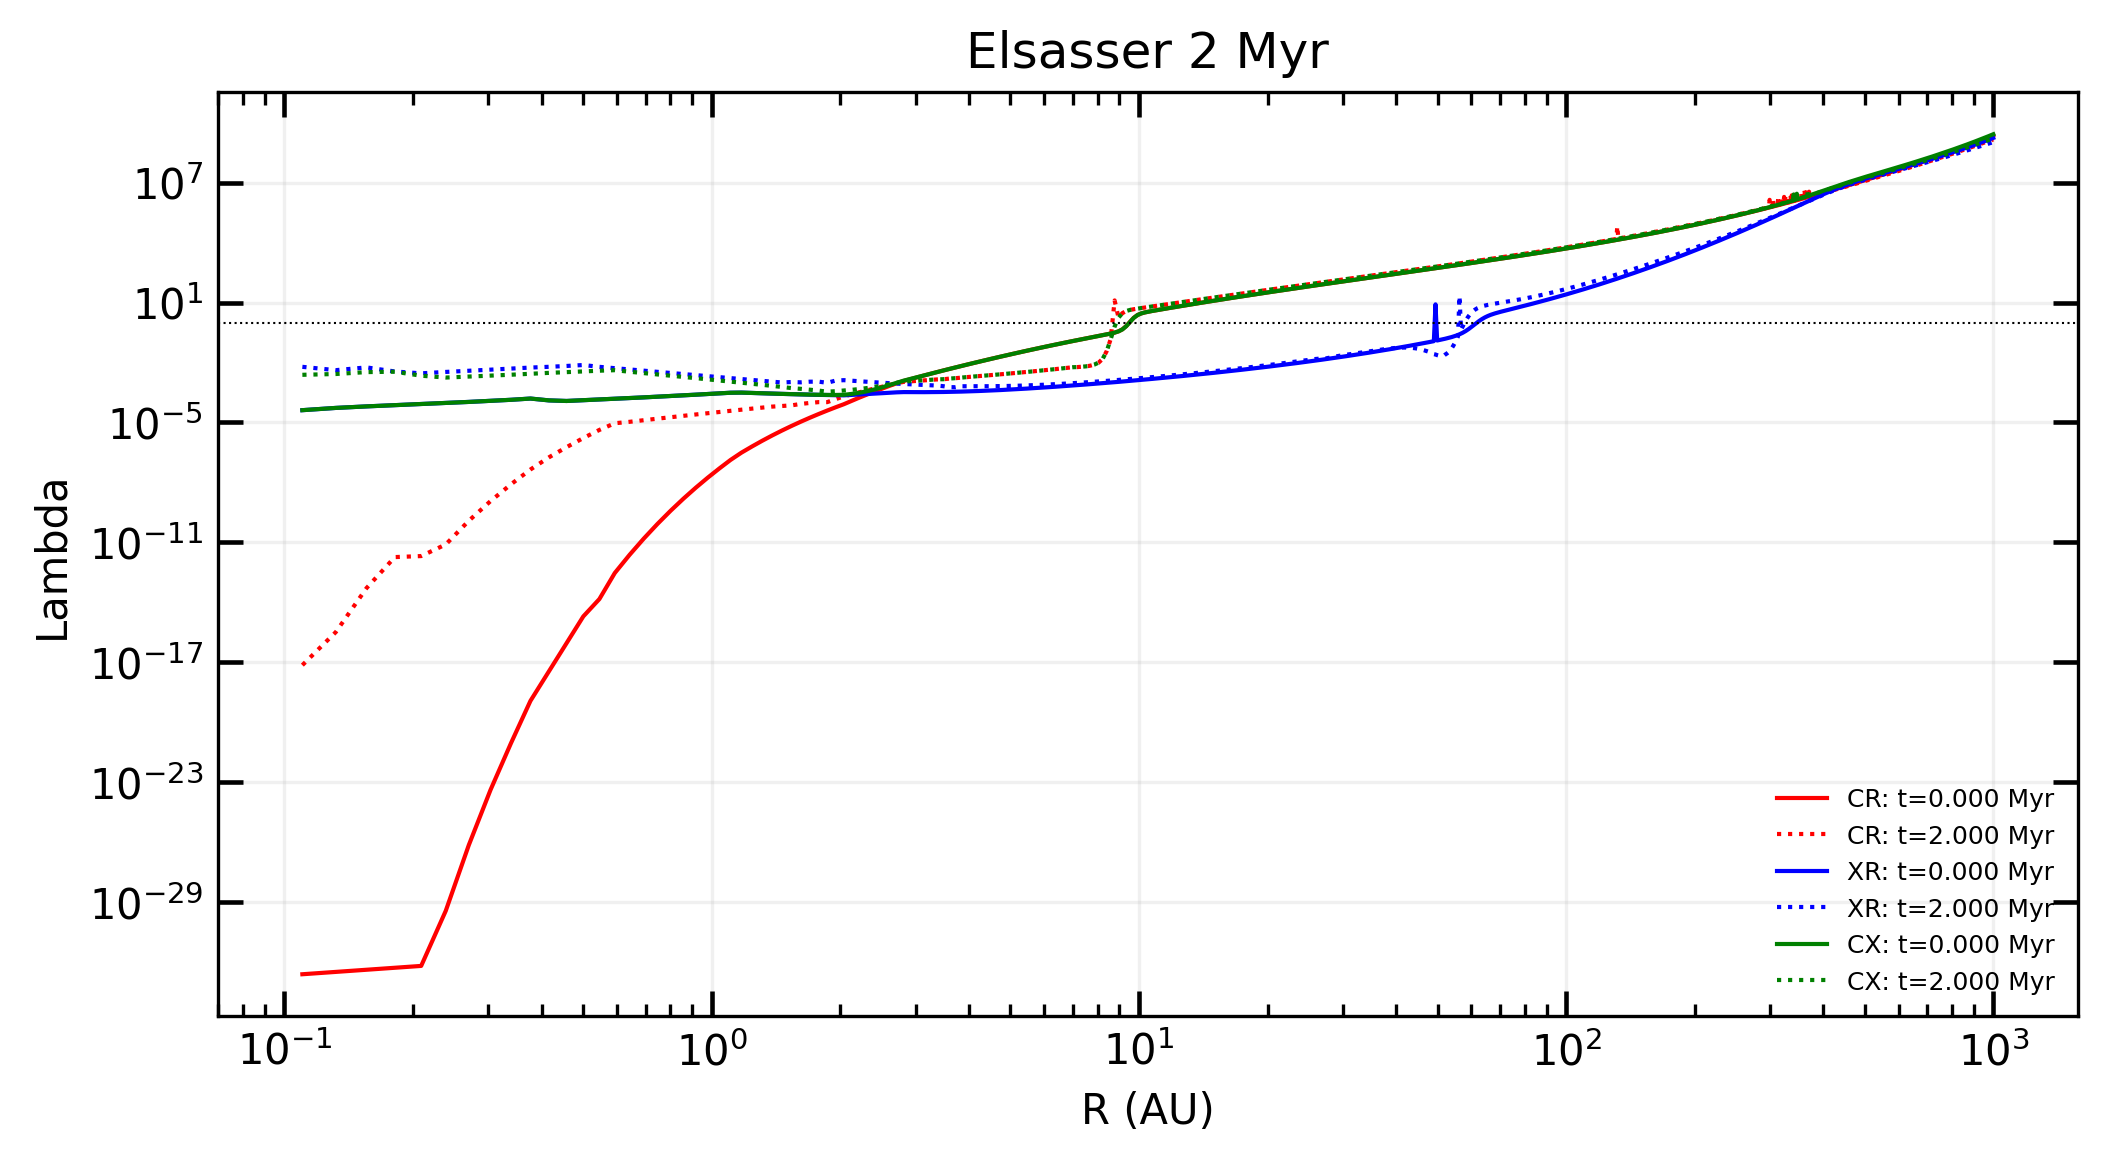

In [18]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Lambda')
plt.title('Elsasser 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, crLam[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crLam[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrLam[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrLam[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxLam[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxLam[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.axhline(1, ls = 'dotted', color = 'black', lw = 0.5)
ax.legend(frameon=False, fontsize=6, loc="best")

# eta Magnetic Diffusivity

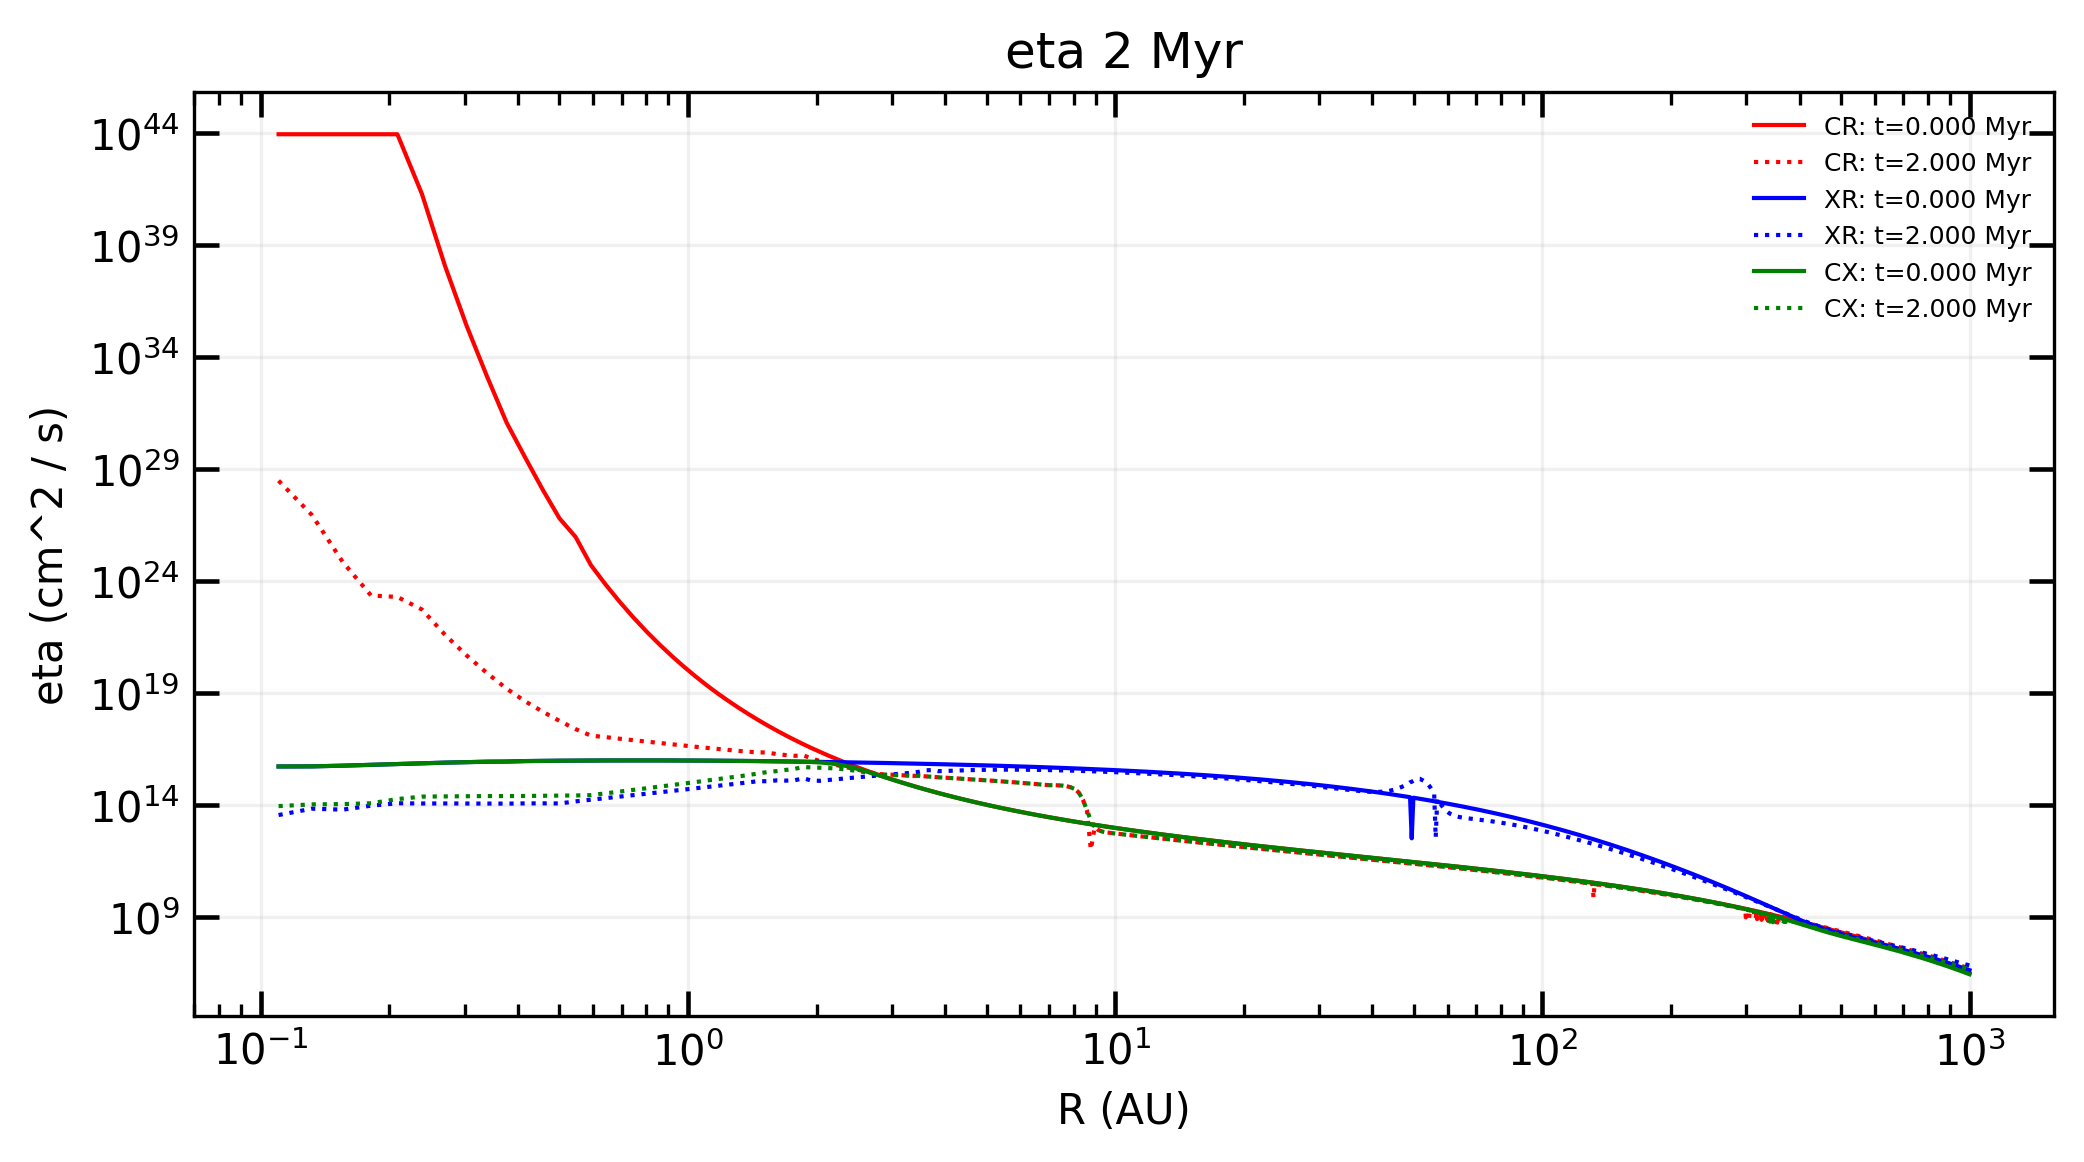

In [19]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('eta (cm^2 / s)')
plt.title('eta 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, creta[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, creta[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xreta[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xreta[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxeta[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxeta[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# n density 

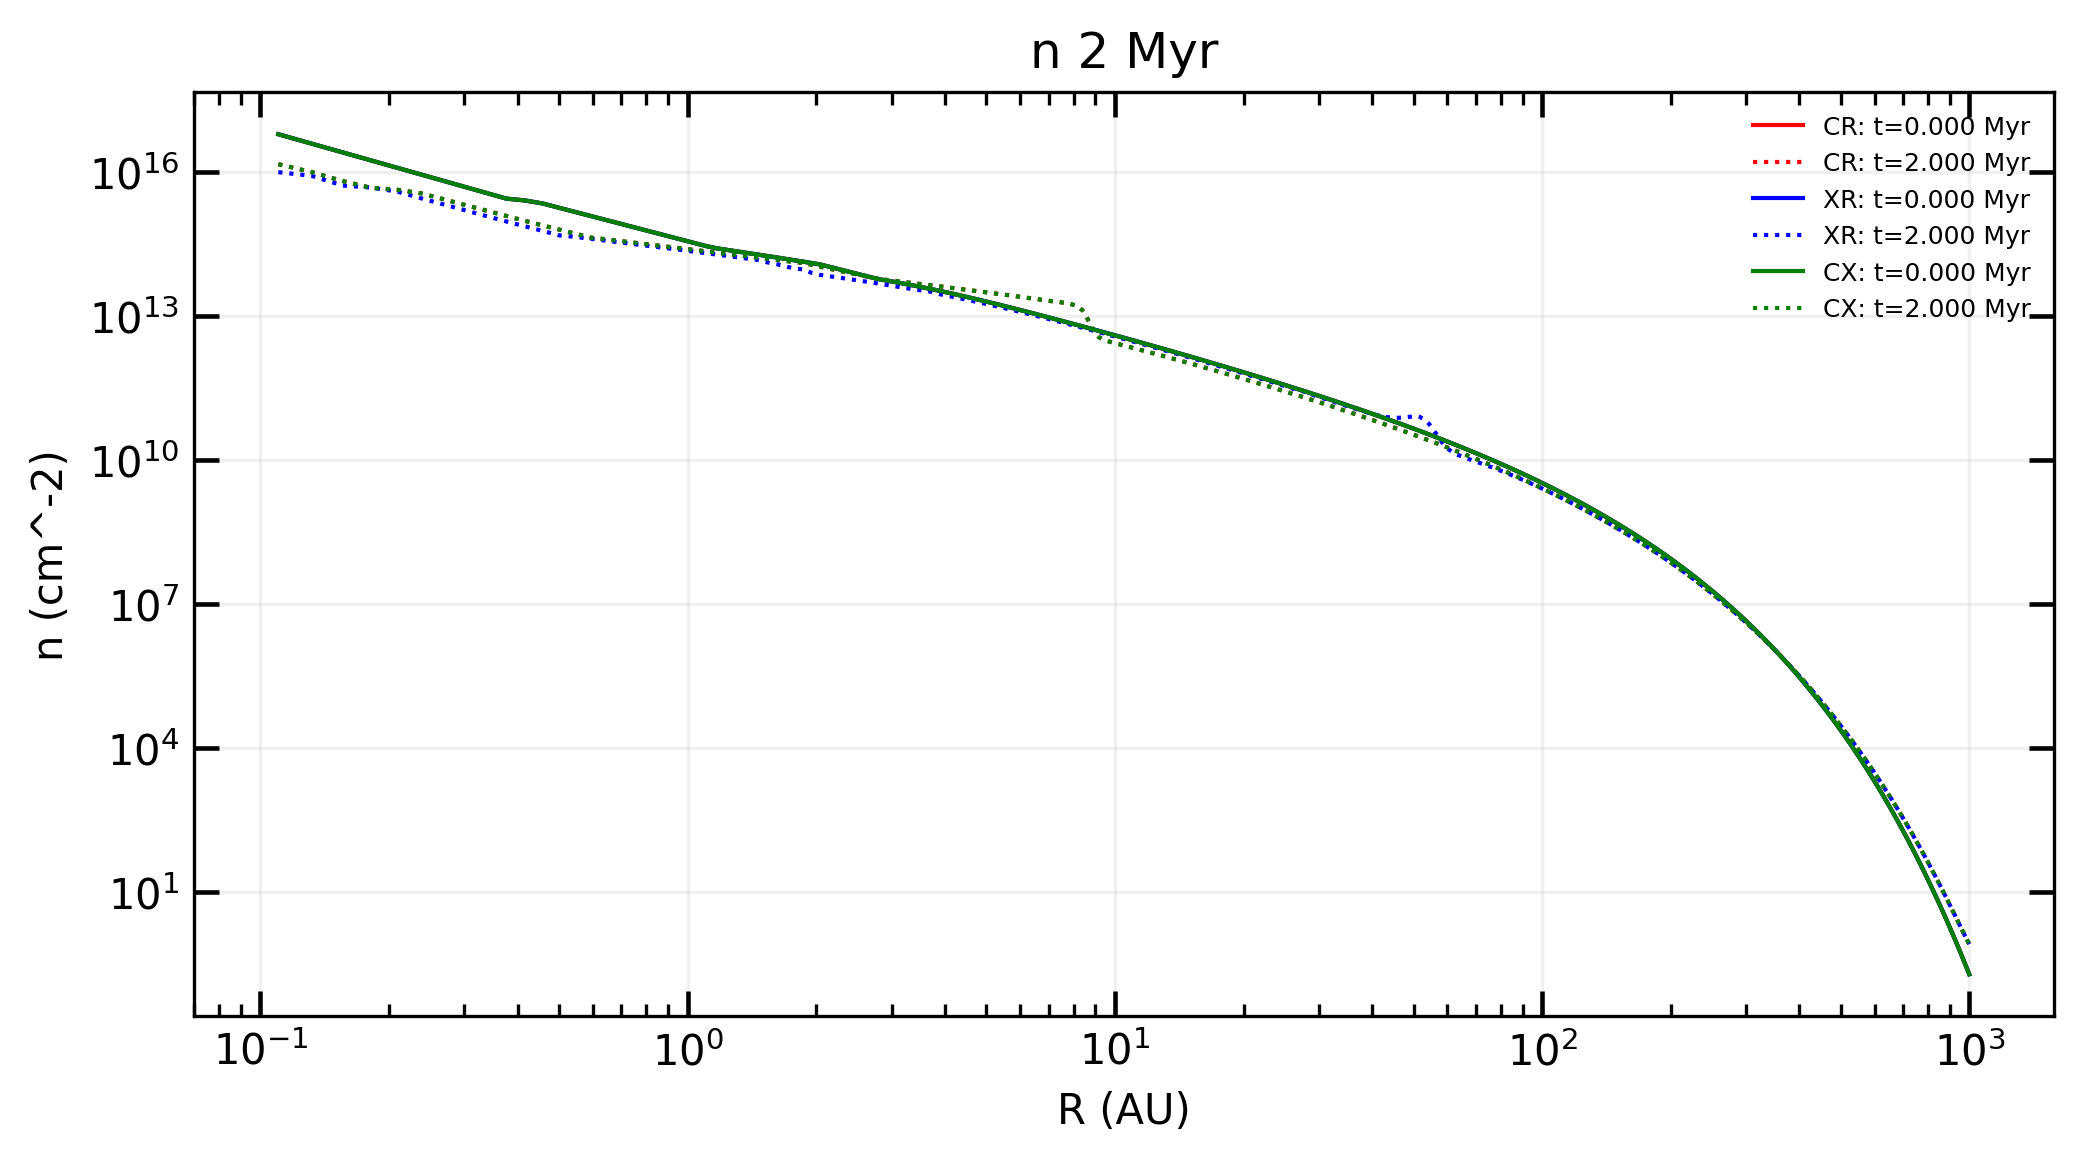

In [20]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('n (cm^-2)')
plt.title('n 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, crn[cridx[0]], linestyle='solid', color='red', label=rf"CR: t={crt[cridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crn[cridx[-1]], linestyle='dotted', color='red', label=rf"CR: t={crt[cridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrn[xridx[0]], linestyle='solid', color='blue', label=rf"XR: t={xrt[xridx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrn[xridx[-1]], linestyle='dotted', color='blue', label=rf"XR: t={xrt[xridx[-1]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxn[cxidx[0]], linestyle='solid', color='green', label=rf"CX: t={cxt[cxidx[0]]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxn[cxidx[-1]], linestyle='dotted', color='green', label=rf"CX: t={cxt[cxidx[-1]]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

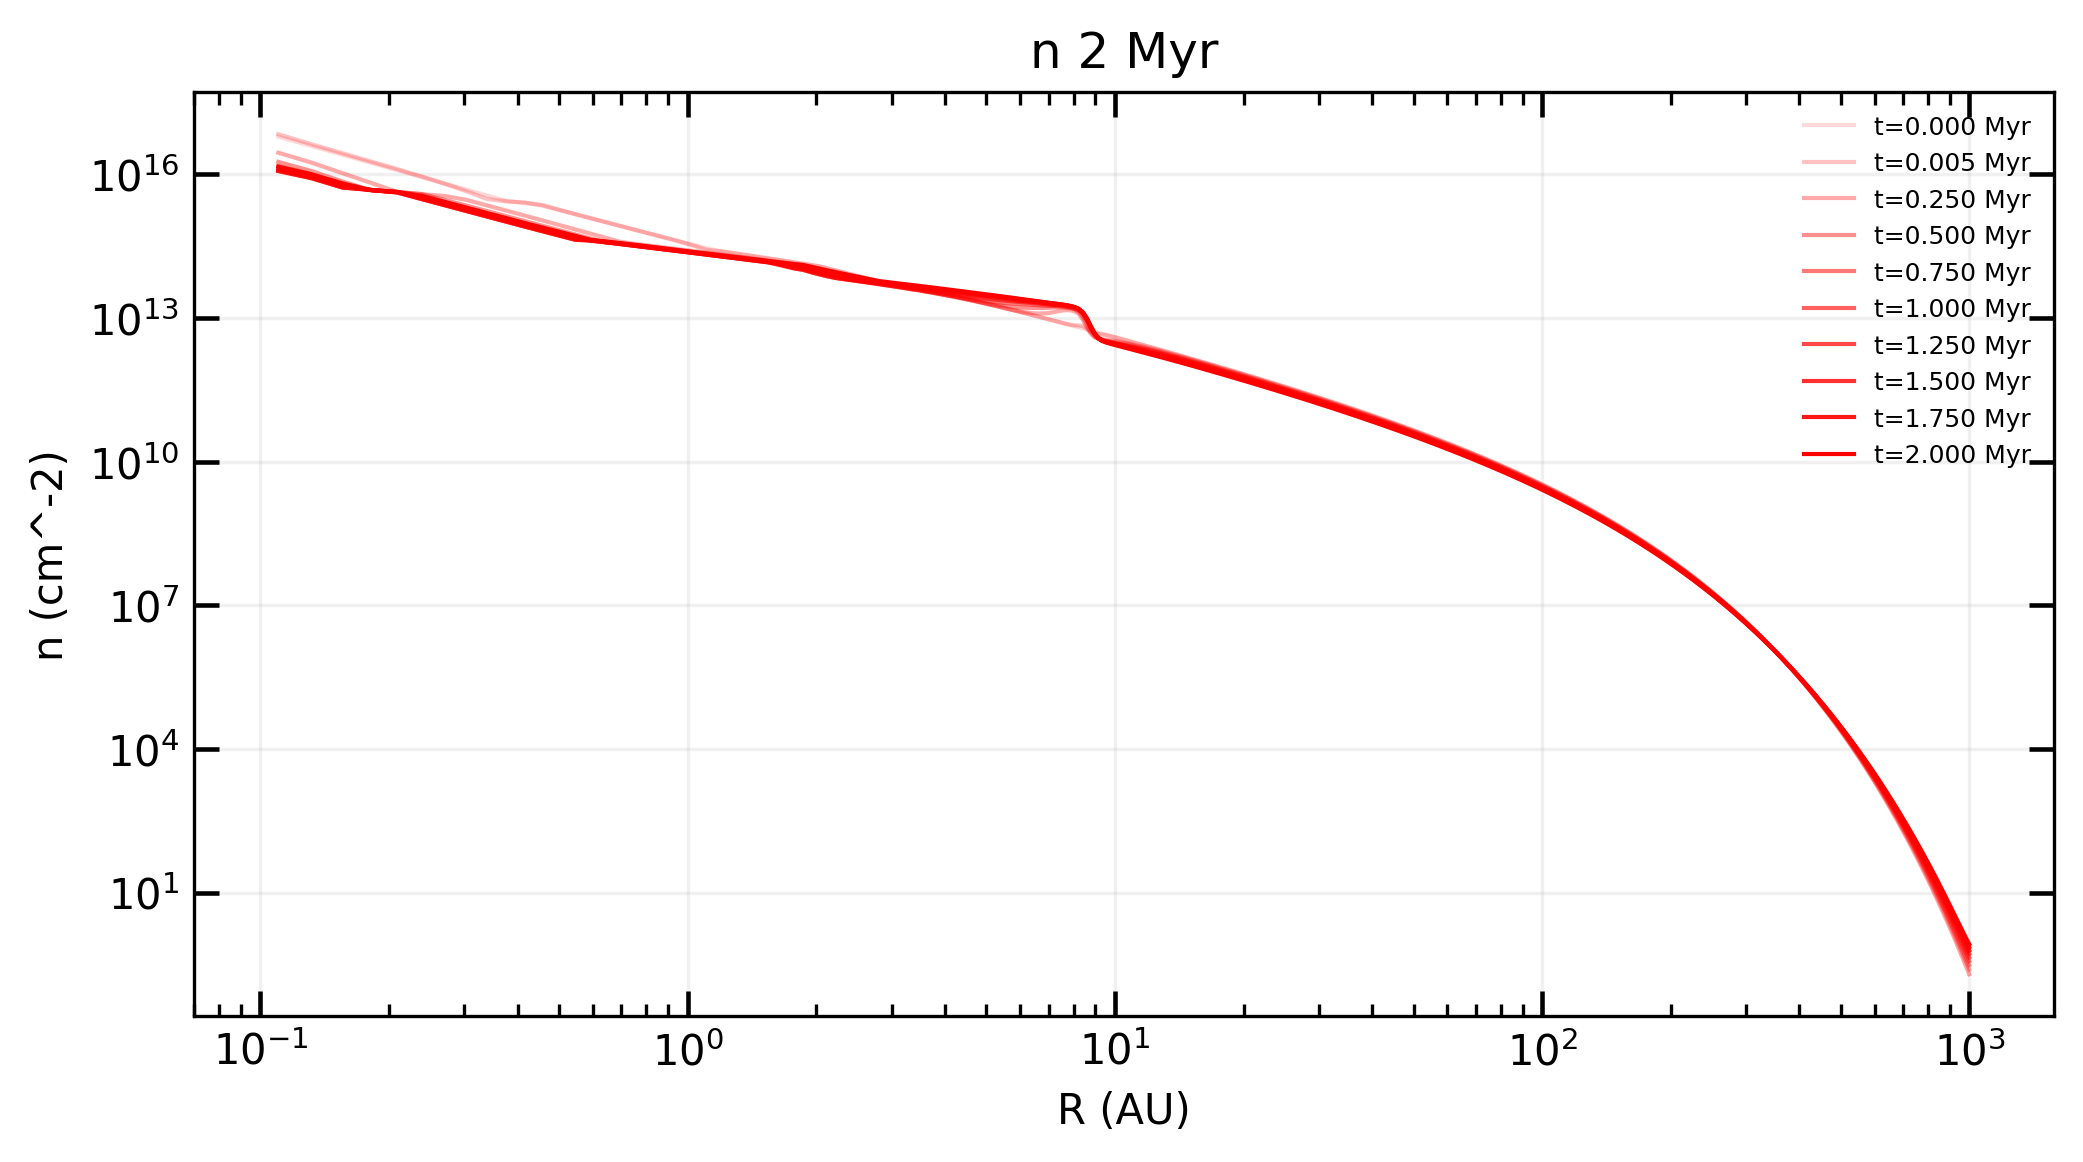

In [21]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('n (cm^-2)')
plt.title('n 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR
ydata = crn
for a_i, i in enumerate(cridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

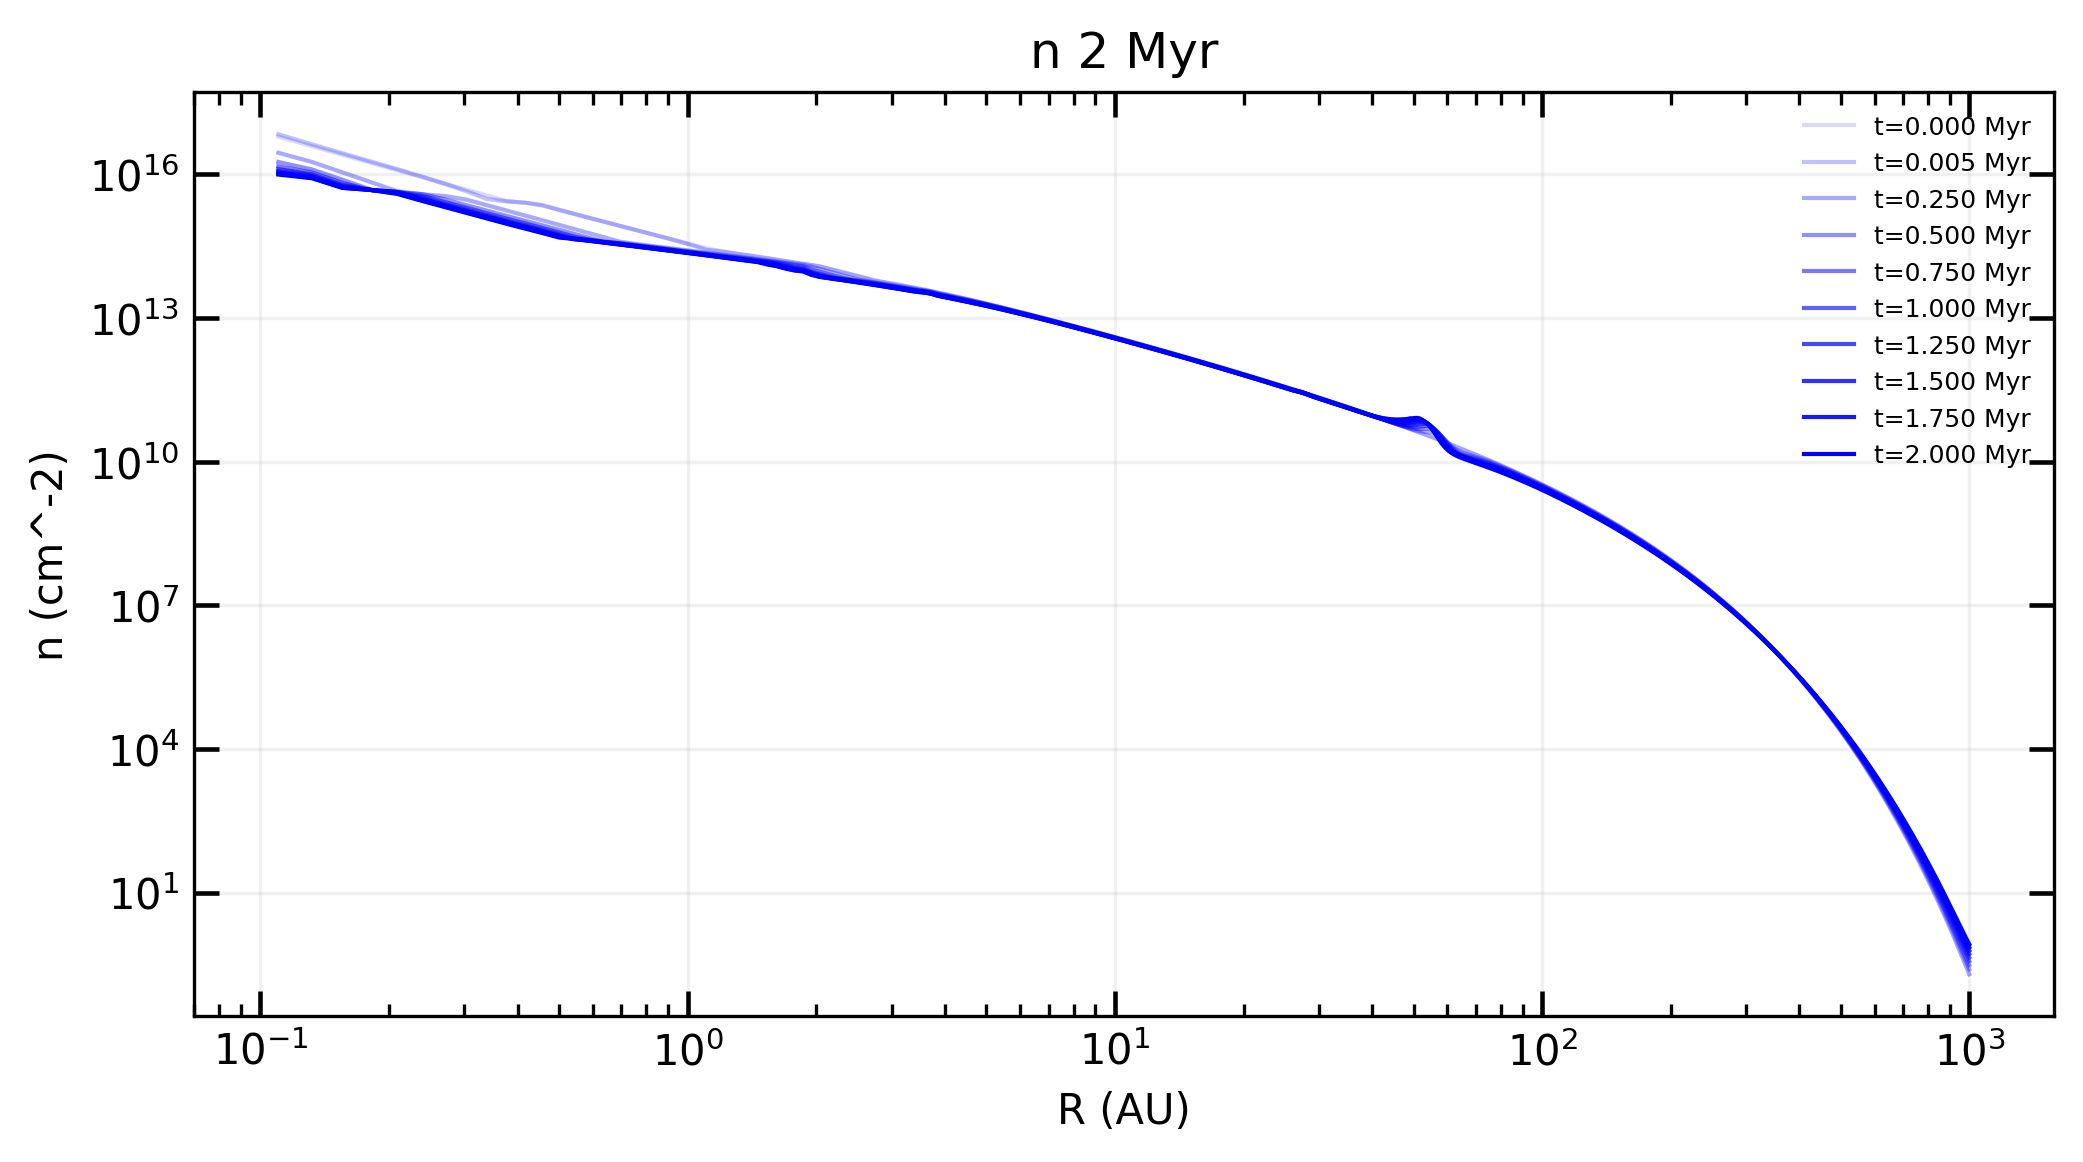

In [22]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('n (cm^-2)')
plt.title('n 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrn
for a_i, i in enumerate(xridx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

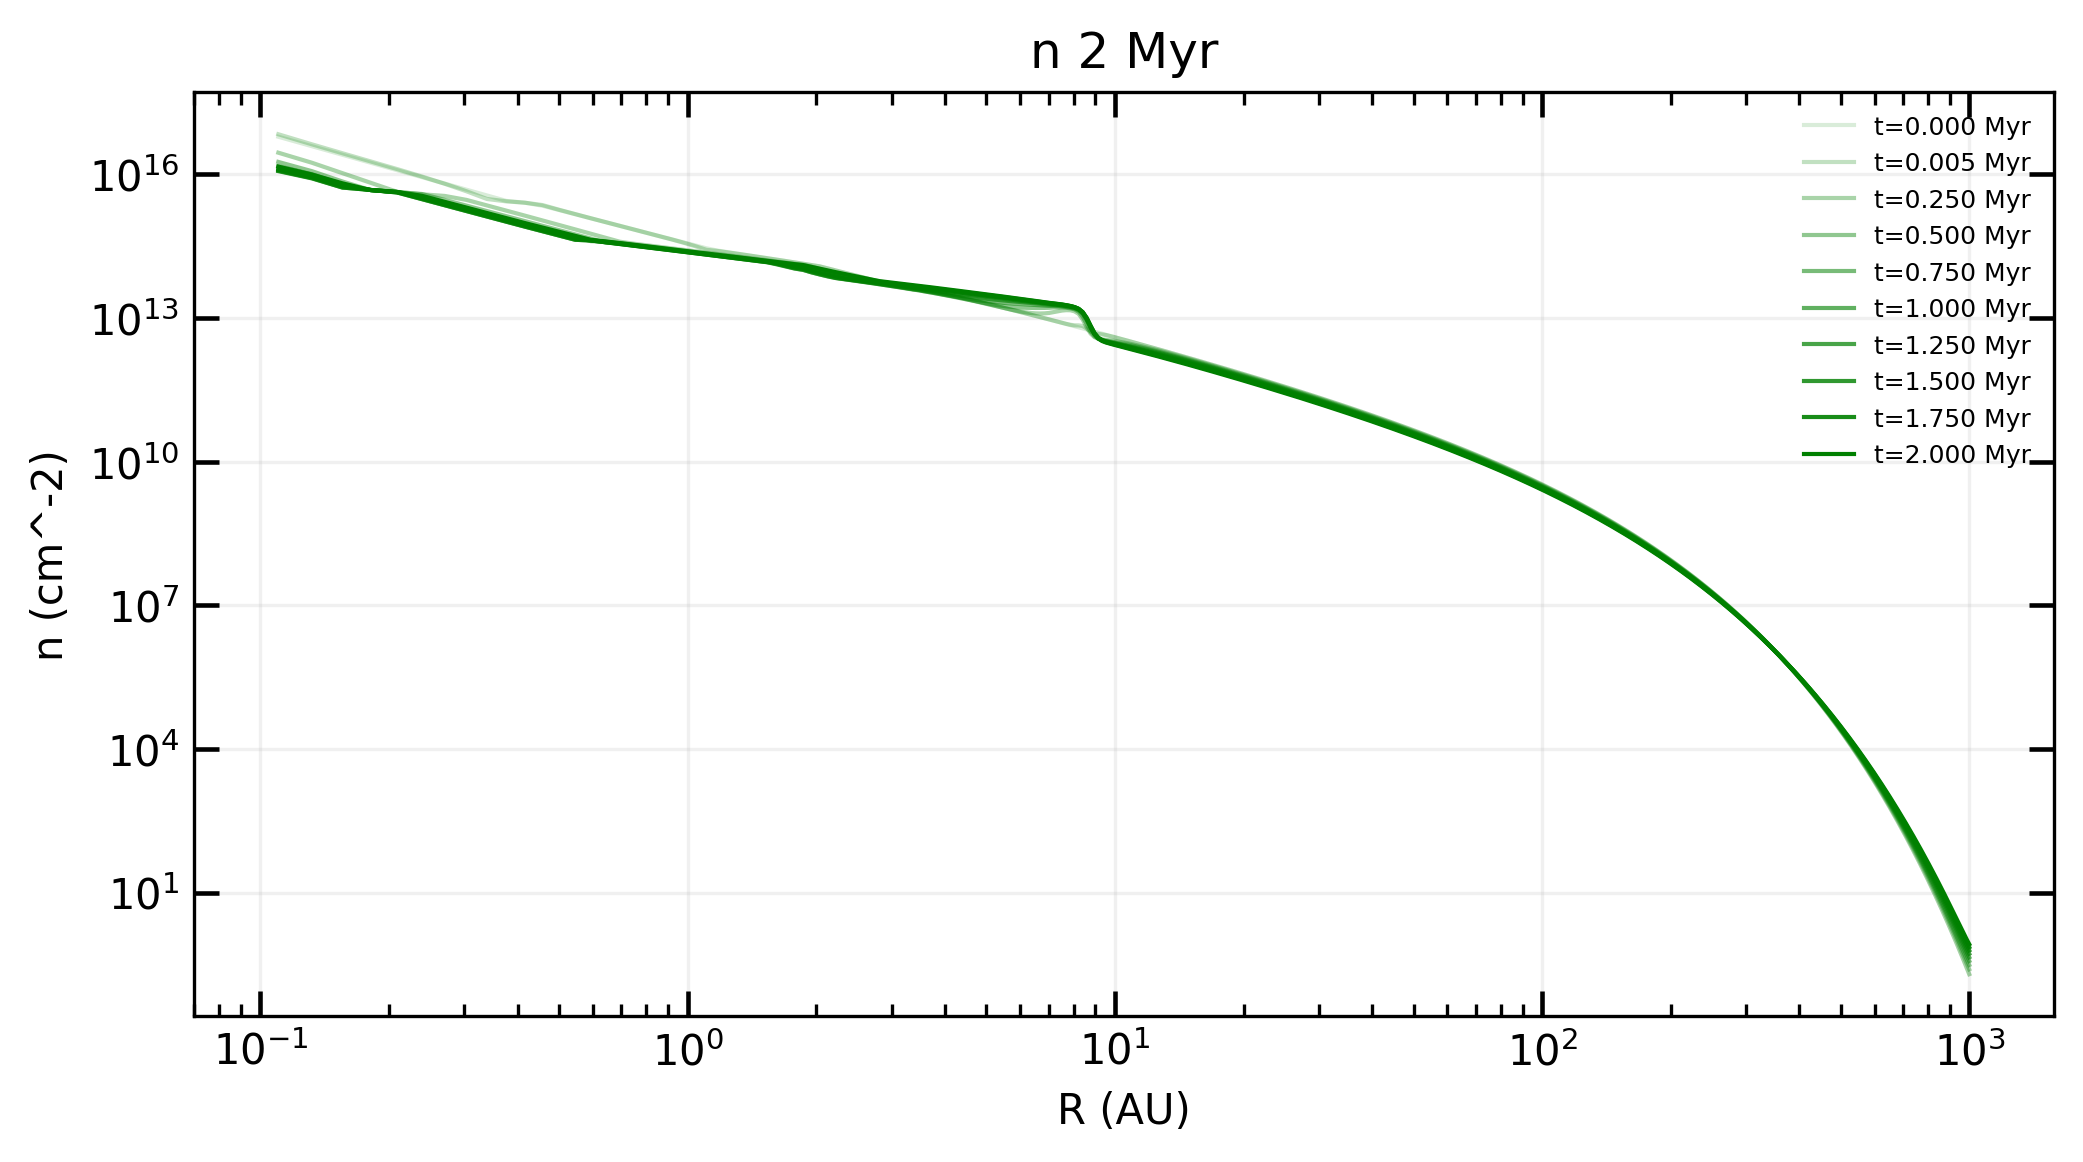

In [23]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('n (cm^-2)')
plt.title('n 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxn
for a_i, i in enumerate(cxidx):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxt[i]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# Sigma

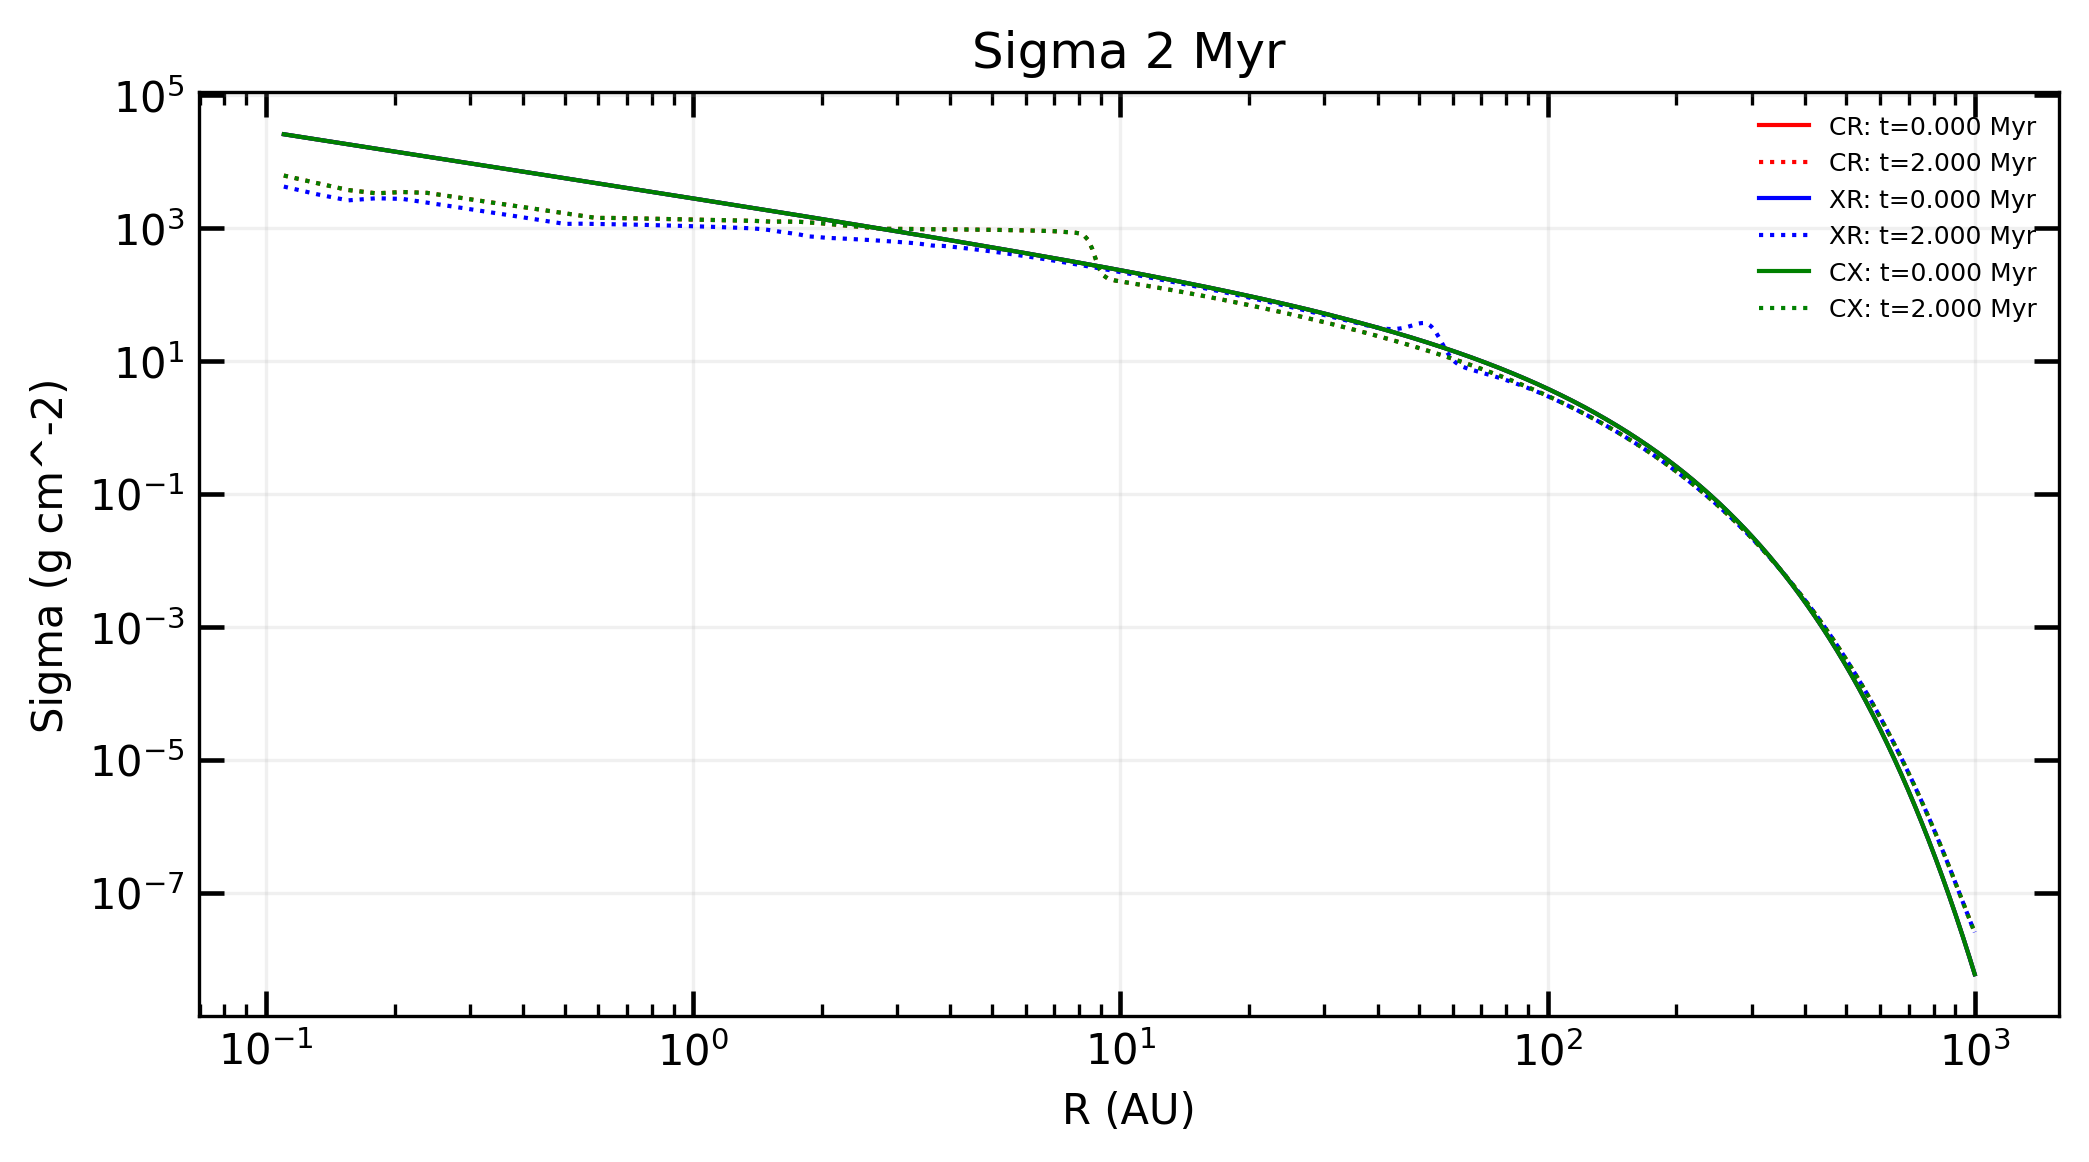

In [24]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('Sigma 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-50,1e-15)

ax.loglog(crR, crSigma_g[0], linestyle='solid', color='red', label=rf"CR: t={crt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crSigma_g[-1], linestyle='dotted', color='red', label=rf"CR: t={crt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrSigma_g[0], linestyle='solid', color='blue', label=rf"XR: t={xrt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrSigma_g[-1], linestyle='dotted', color='blue', label=rf"XR: t={xrt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxSigma_g[0], linestyle='solid', color='green', label=rf"CX: t={cxt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxSigma_g[-1], linestyle='dotted', color='green', label=rf"CX: t={cxt[-1]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

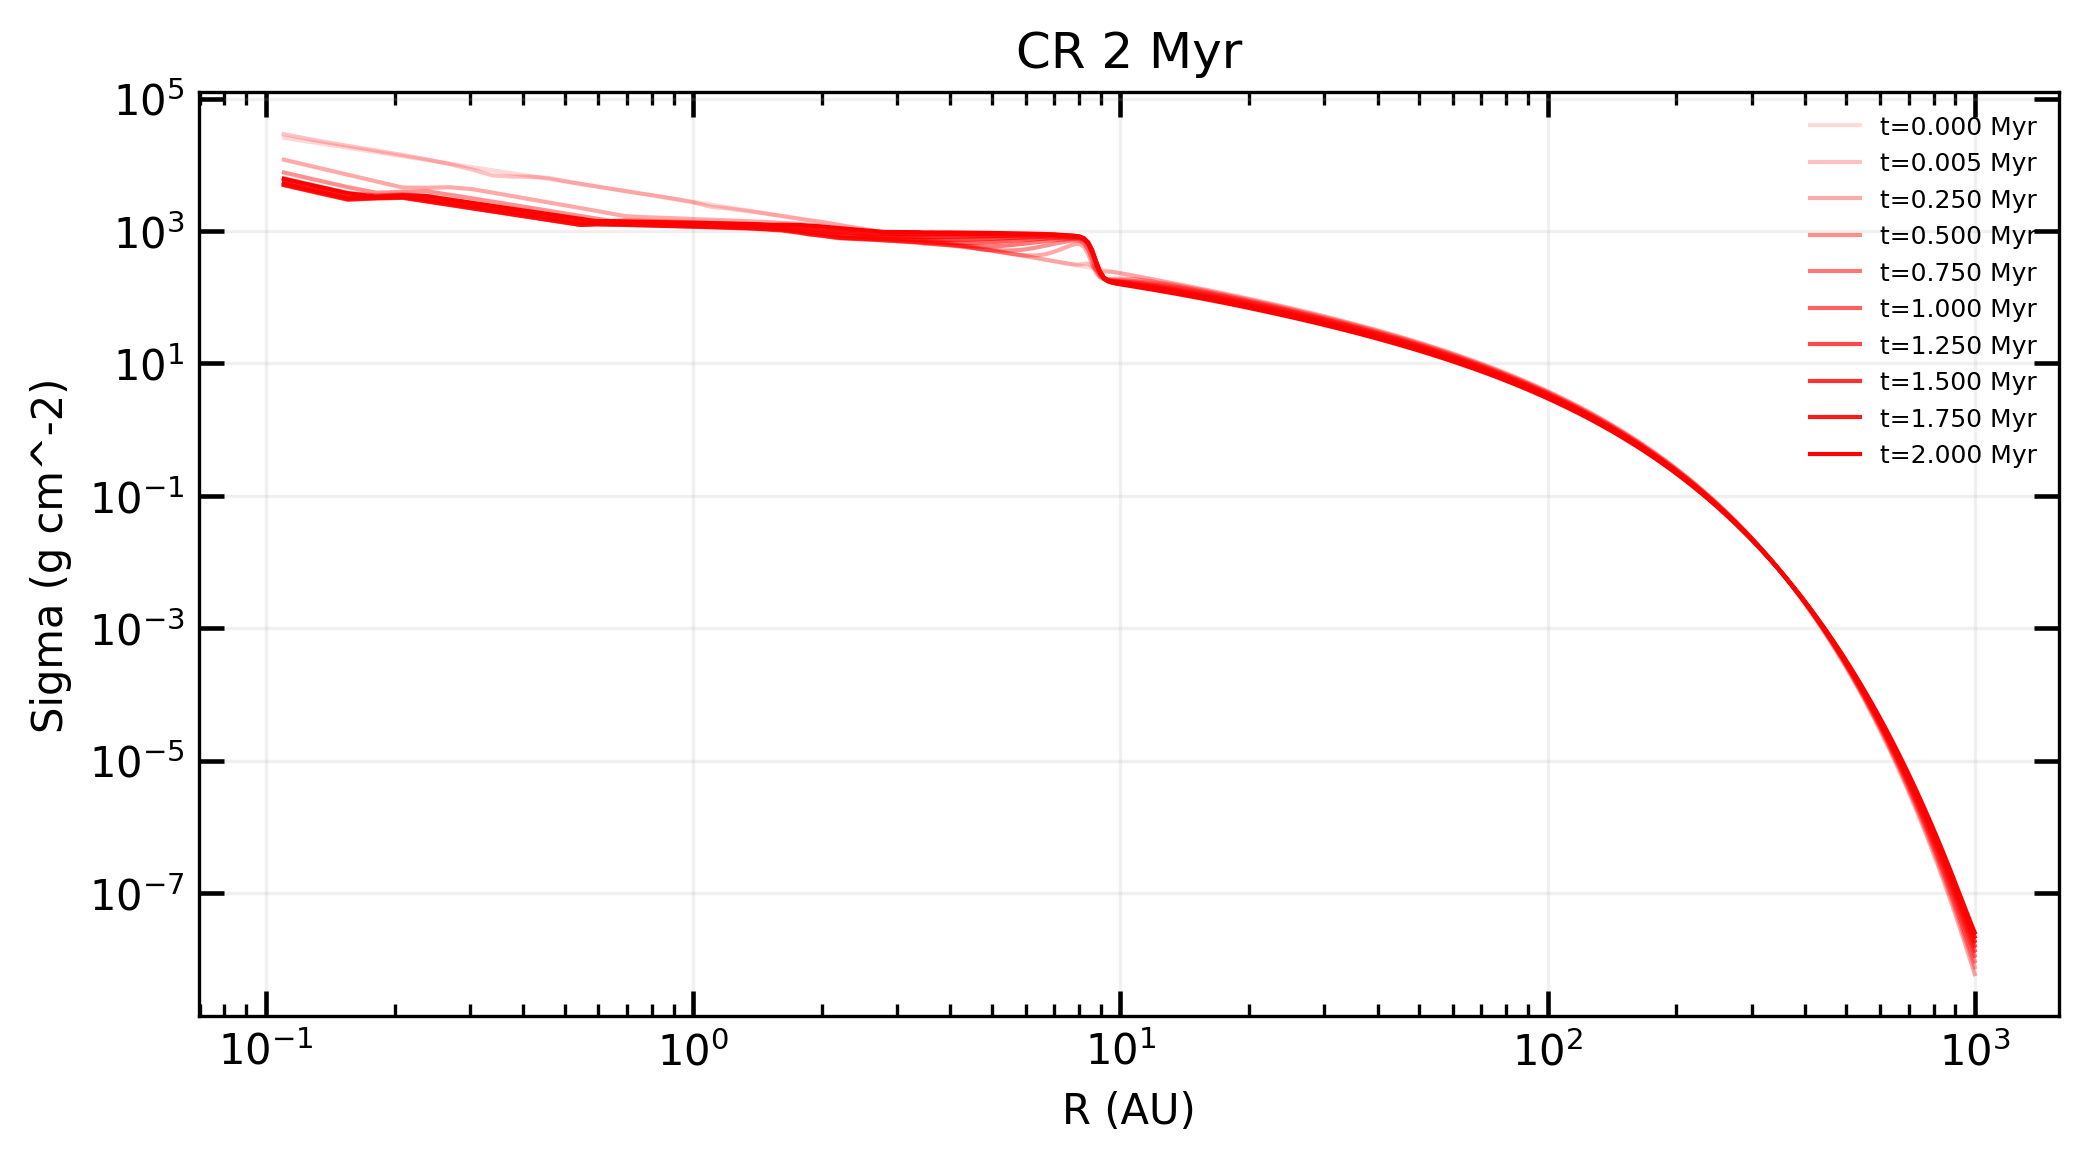

In [25]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('CR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR
ydata = crSigma_g
for a_i, i in enumerate(range(0,10)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

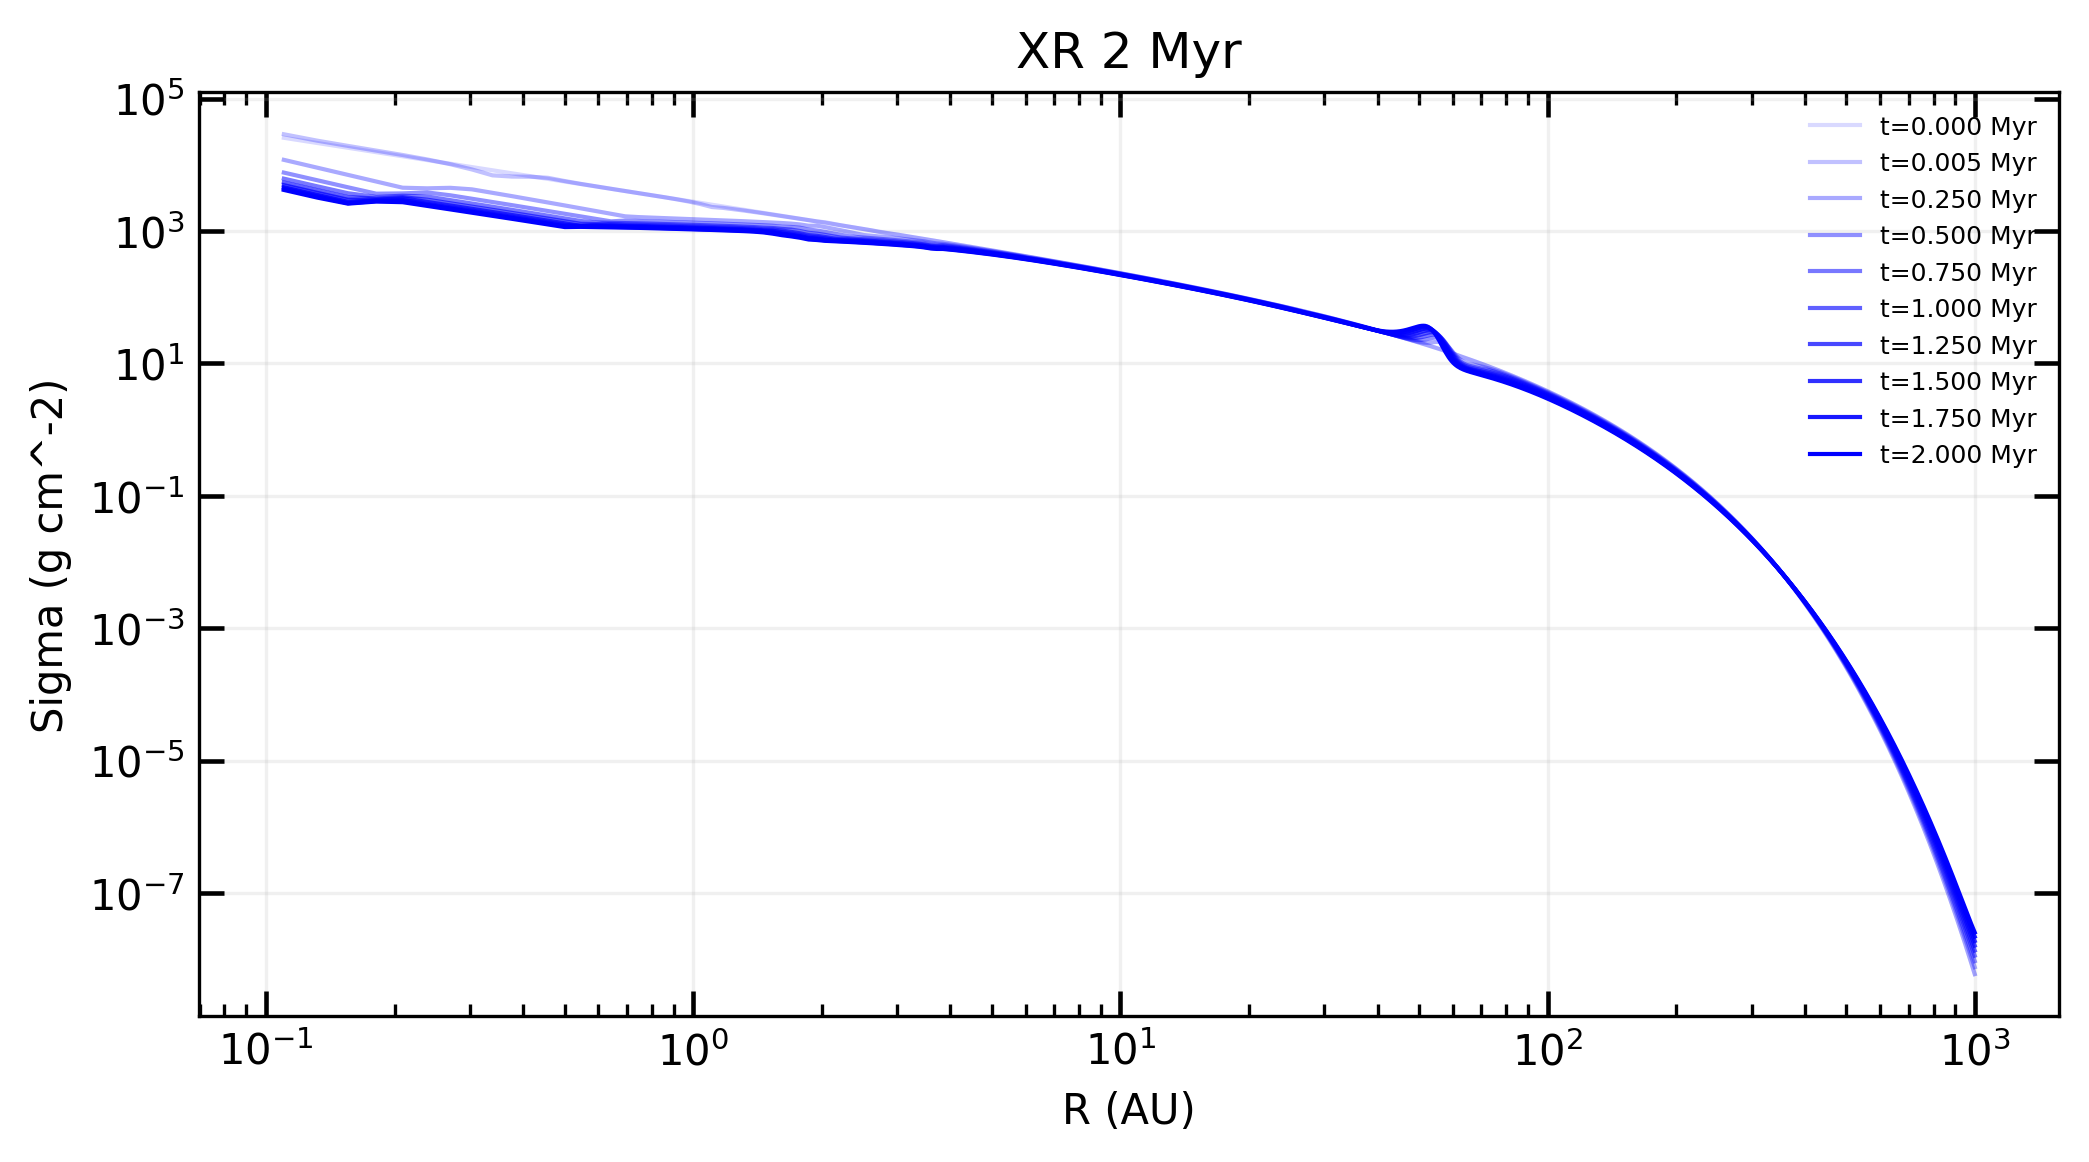

In [26]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('XR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrSigma_g
for a_i, i in enumerate(range(0,10)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

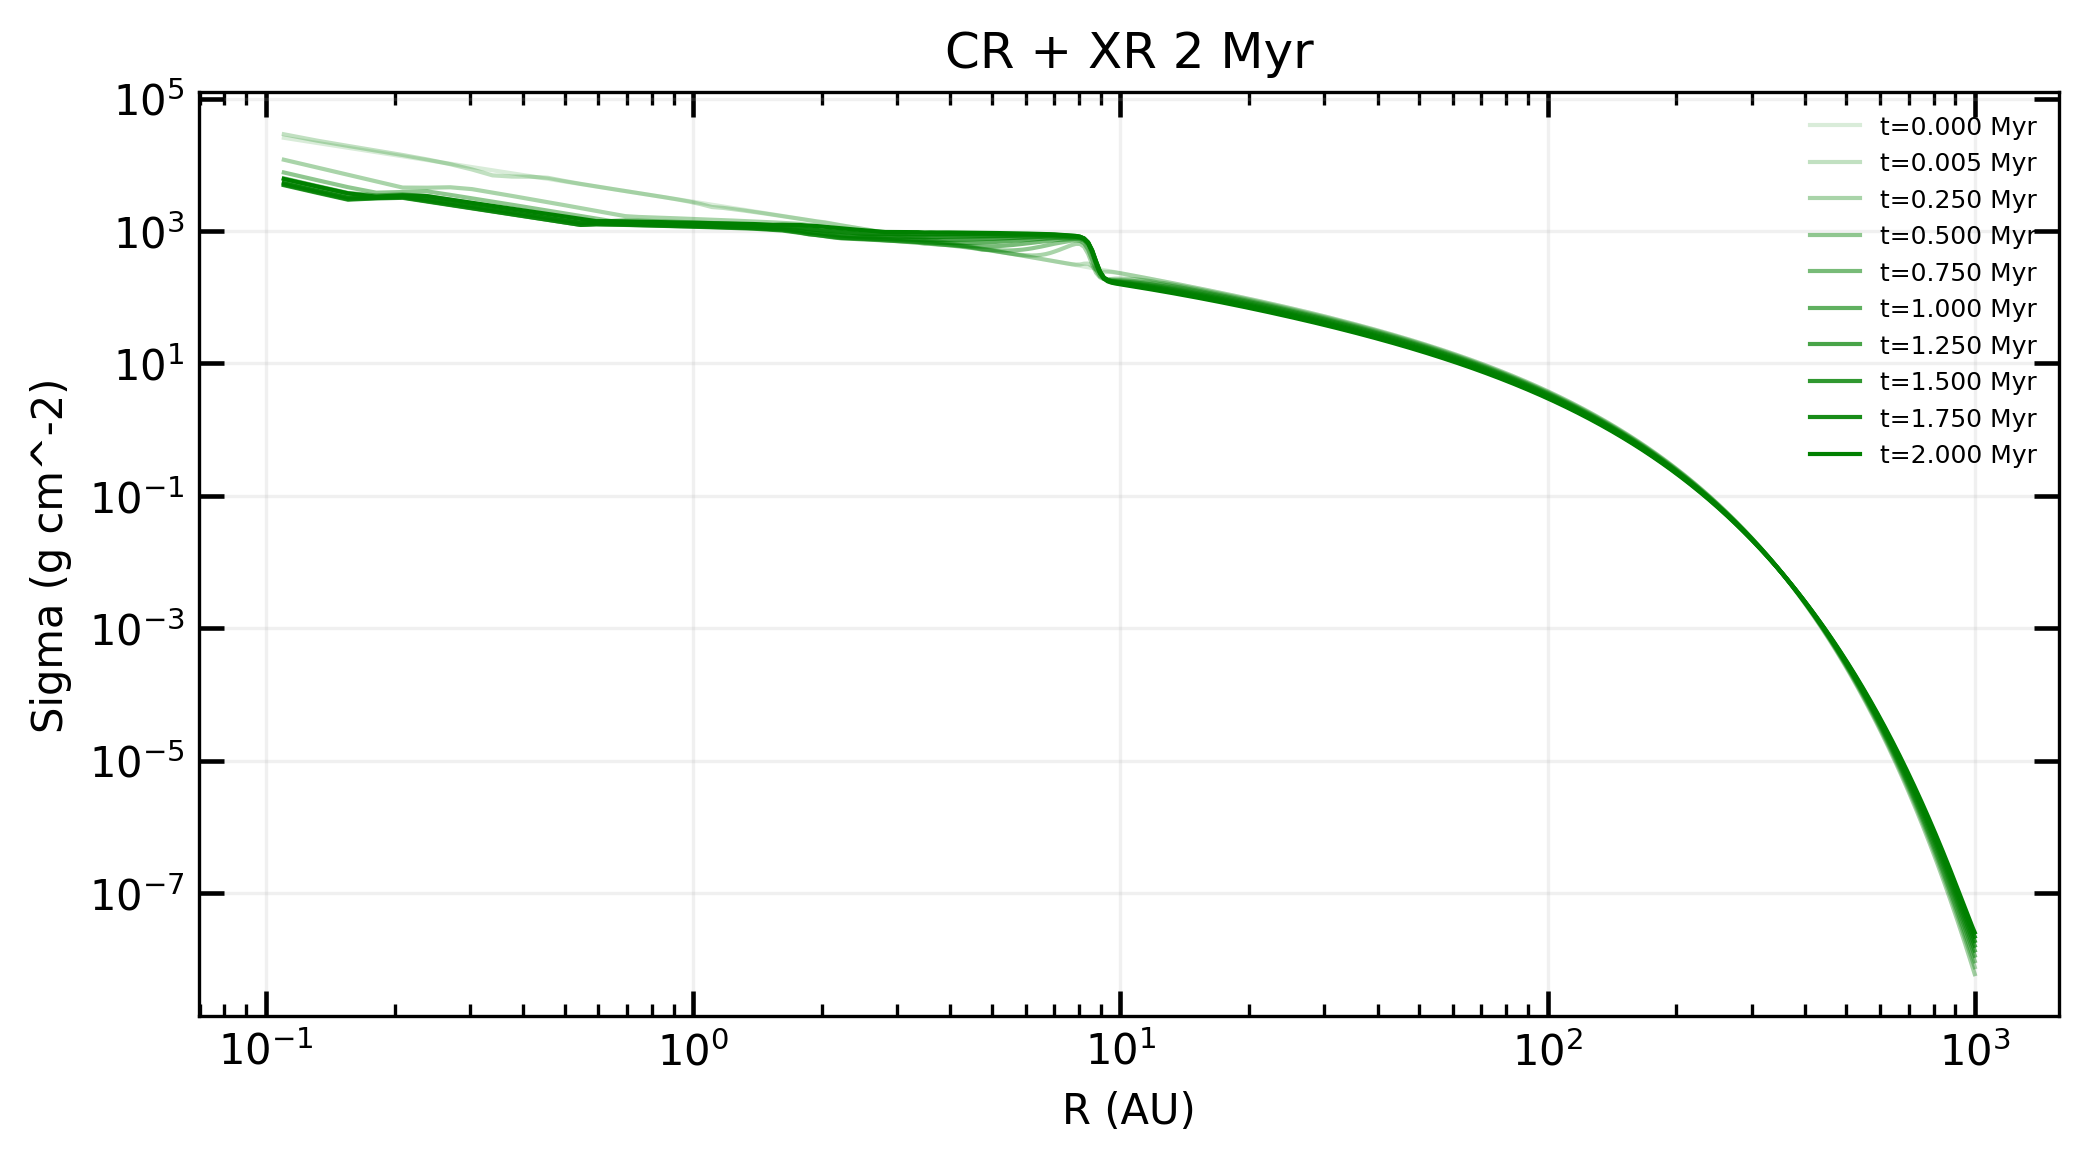

In [27]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('Sigma (g cm^-2)')
plt.title('CR + XR 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = cxR
ydata = cxSigma_g
for a_i, i in enumerate(range(0,10)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='green', alpha=alphas[a_i],
                label=rf"t={cxtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

# alpha

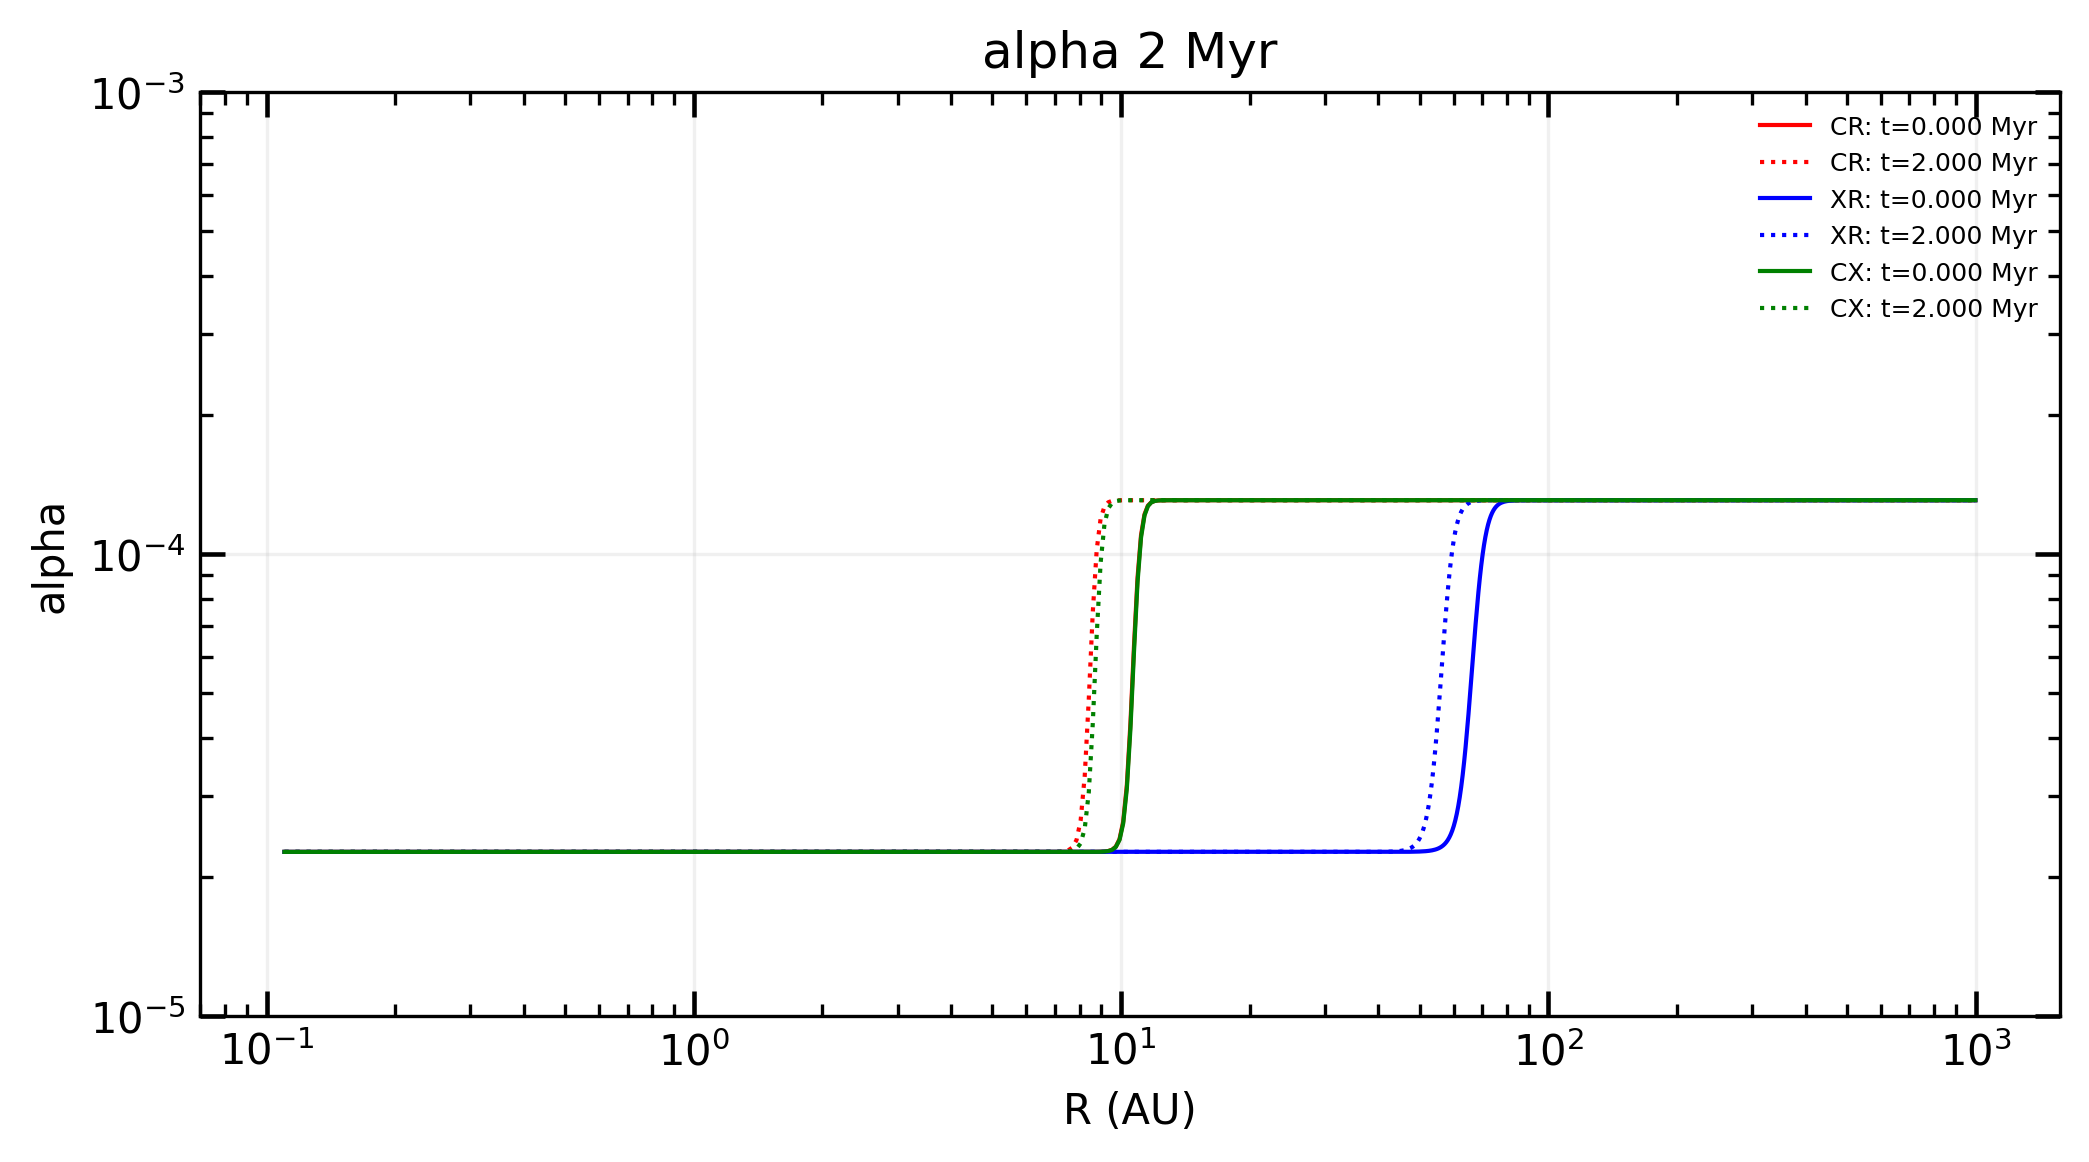

In [28]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('alpha')
plt.title('alpha 2 Myr')
#ax.set_xlim(8,10)
ax.set_ylim(1e-5,1e-3)

ax.loglog(crR, cralpha[0], linestyle='solid', color='red', label=rf"CR: t={crt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, cralpha[-1], linestyle='dotted', color='red', label=rf"CR: t={crt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xralpha[0], linestyle='solid', color='blue', label=rf"XR: t={xrt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xralpha[-1], linestyle='dotted', color='blue', label=rf"XR: t={xrt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxalpha[0], linestyle='solid', color='green', label=rf"CX: t={cxt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxalpha[-1], linestyle='dotted', color='green', label=rf"CX: t={cxt[-1]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

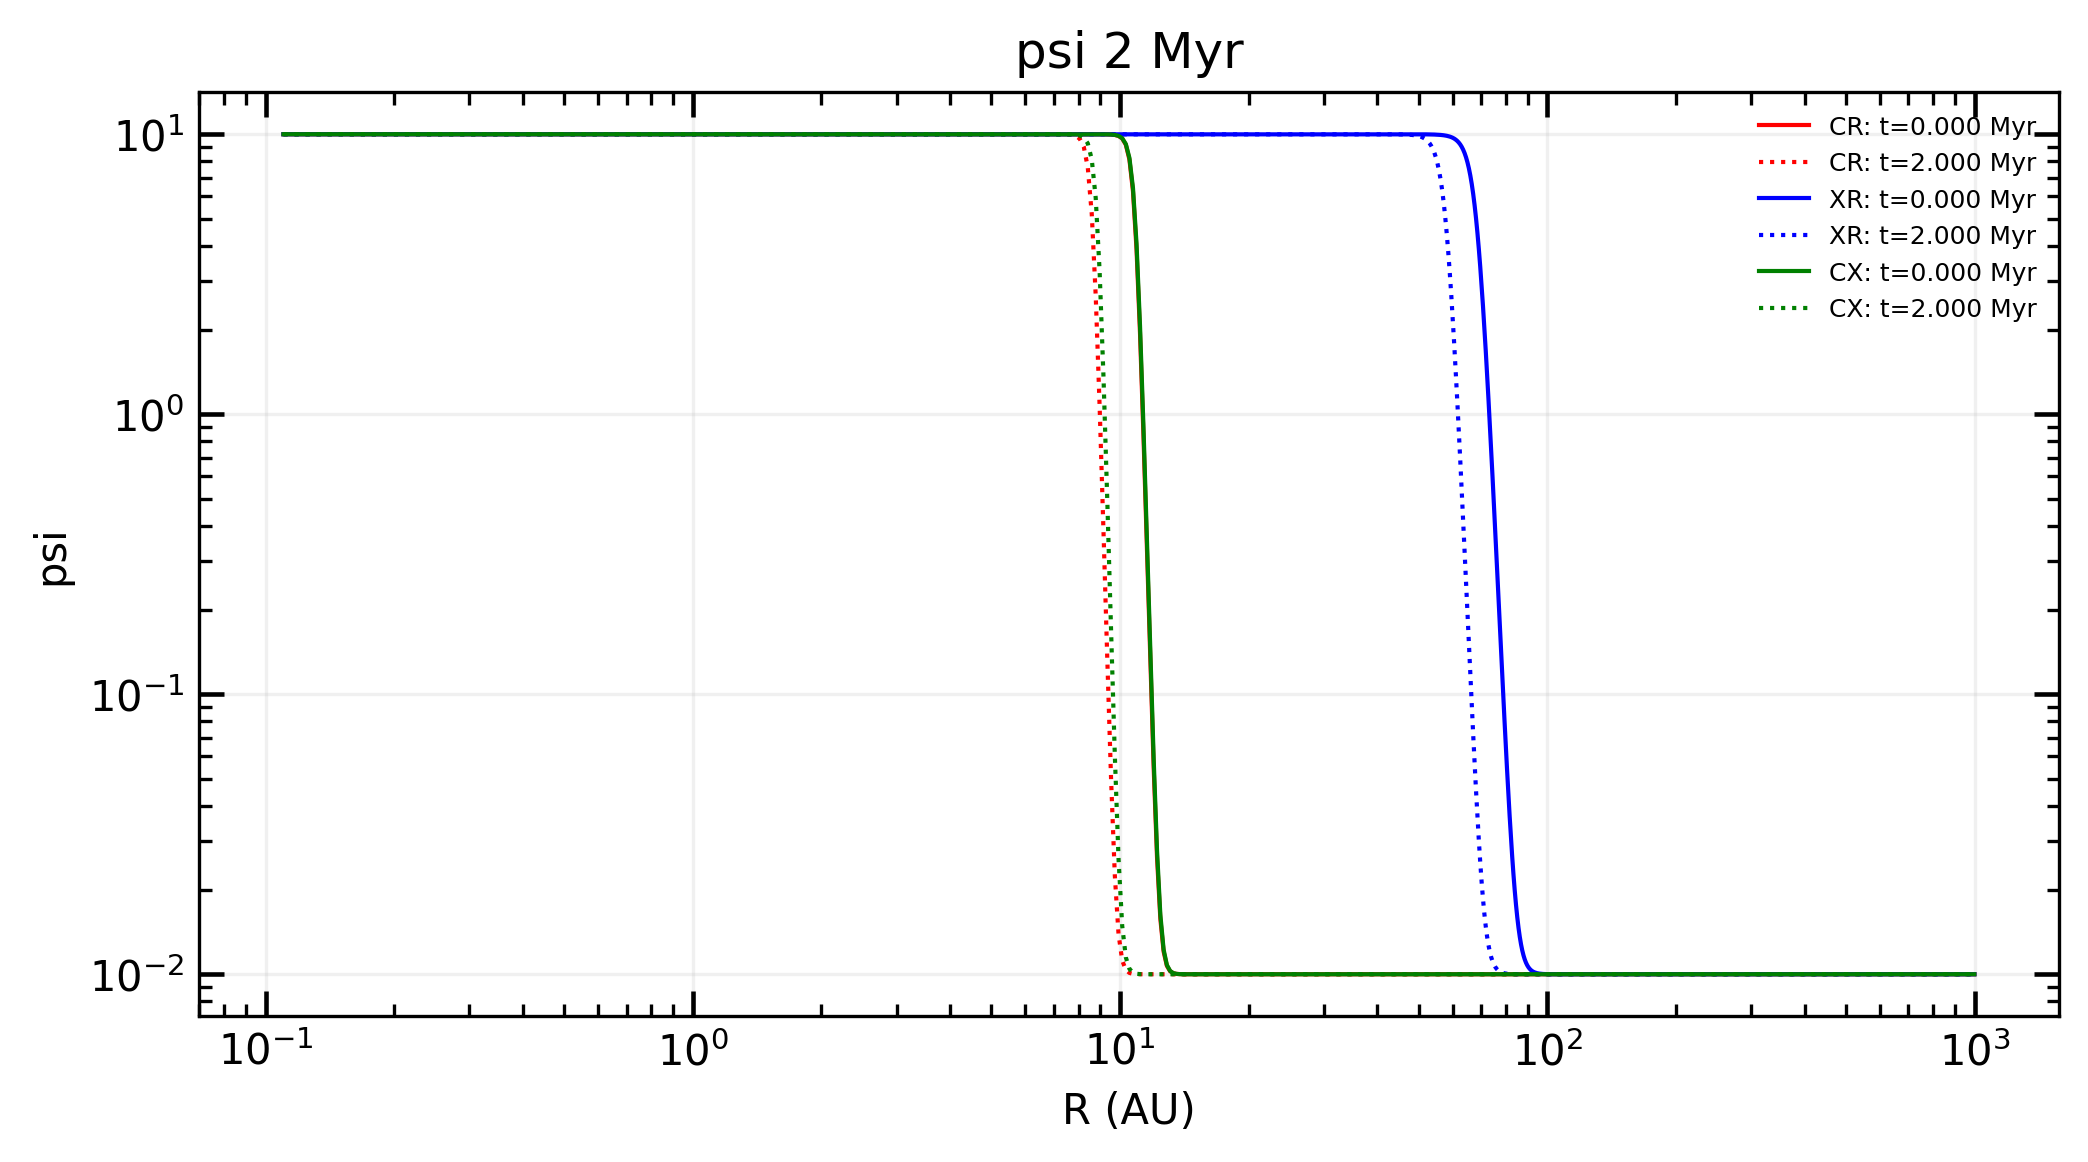

In [29]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('psi')
plt.title('psi 2 Myr')
#ax.set_xlim(8,10)
#ax.set_ylim(1e-5,1e-3)

ax.loglog(crR, crpsi[0], linestyle='solid', color='red', label=rf"CR: t={crt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(crR, crpsi[-1], linestyle='dotted', color='red', label=rf"CR: t={crt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrpsi[0], linestyle='solid', color='blue', label=rf"XR: t={xrt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(xrR, xrpsi[-1], linestyle='dotted', color='blue', label=rf"XR: t={xrt[-1]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxpsi[0], linestyle='solid', color='green', label=rf"CX: t={cxt[0]/1e6:.3f} Myr", lw = 1.0)
ax.loglog(cxR, cxpsi[-1], linestyle='dotted', color='green', label=rf"CX: t={cxt[-1]/1e6:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

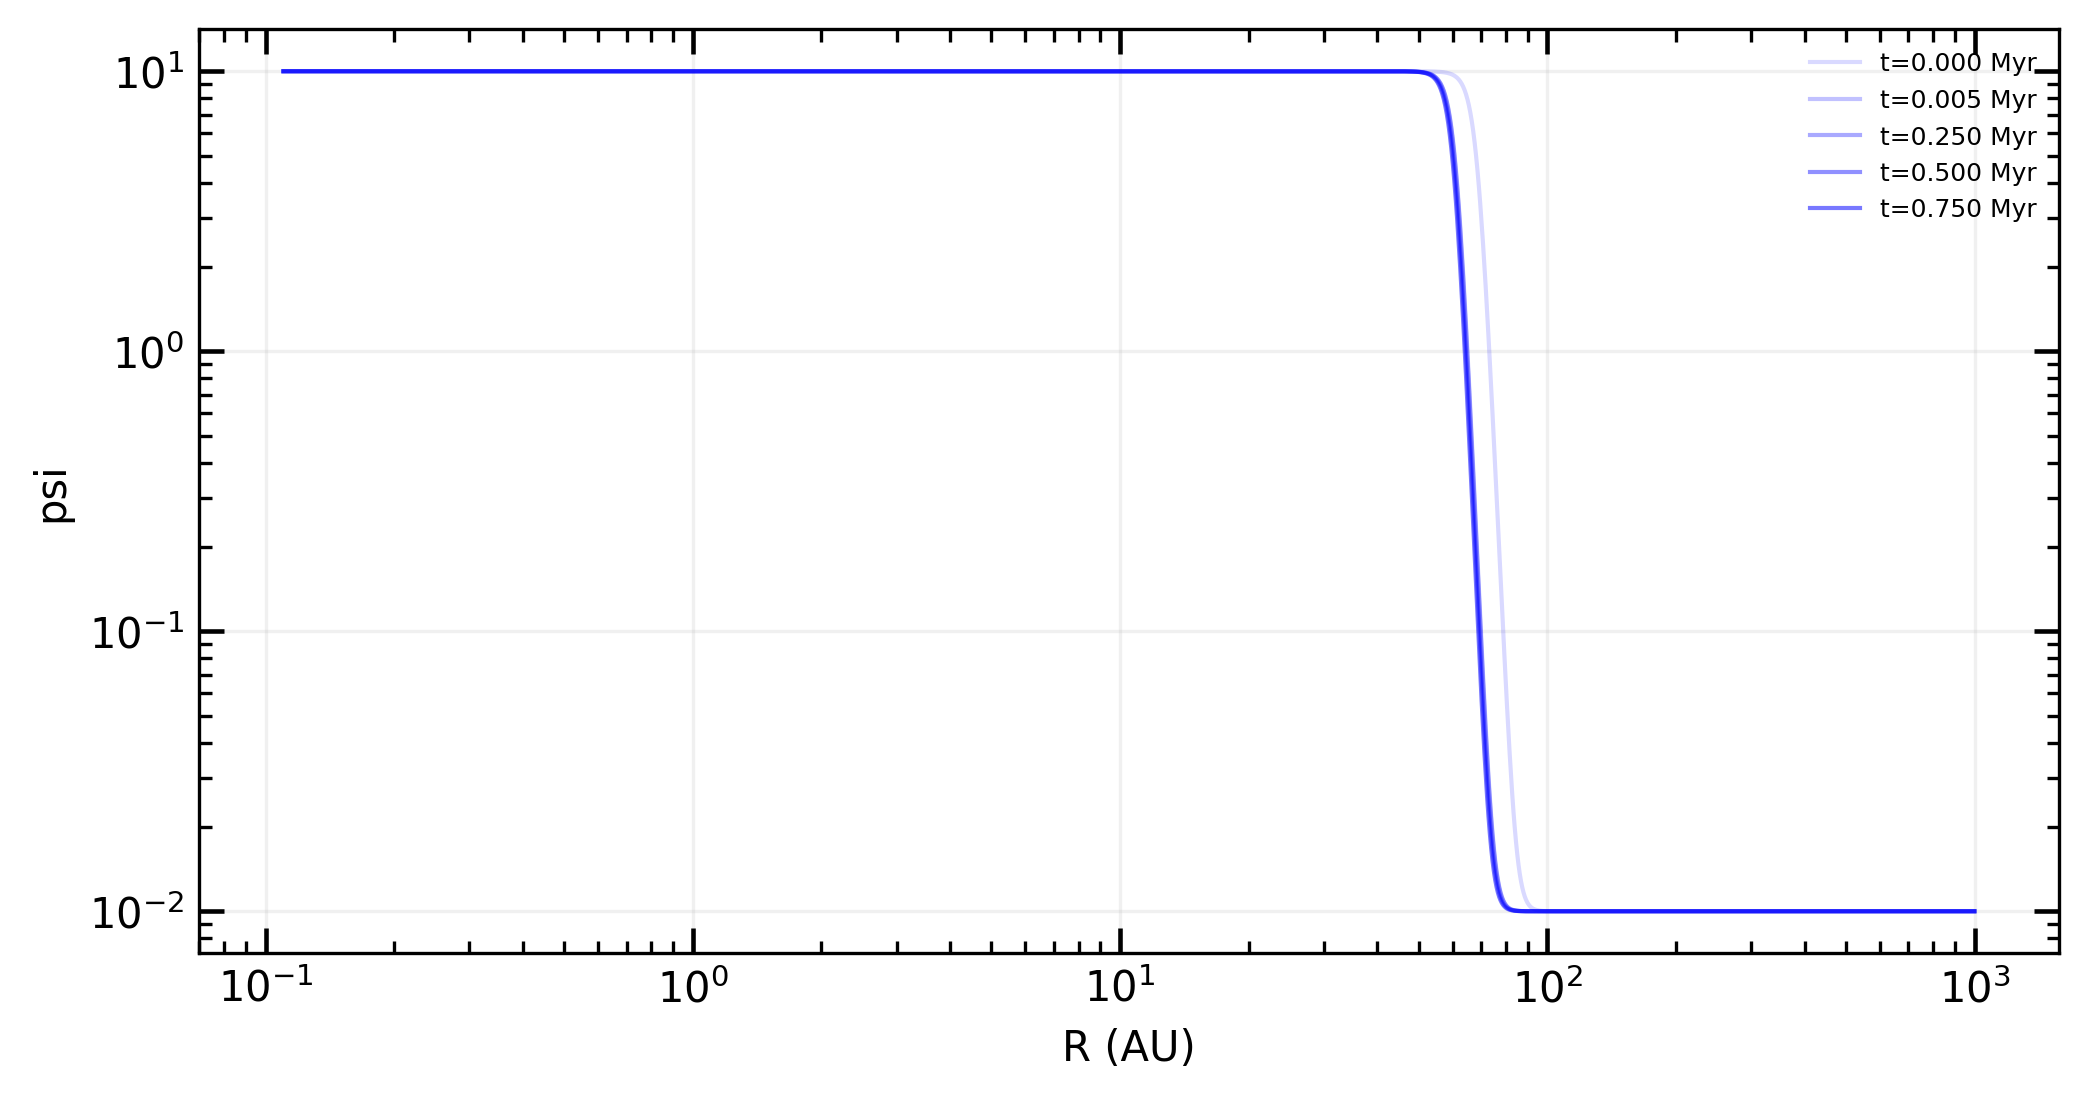

In [30]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('psi')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = xrR
ydata = xrpsi
for a_i, i in enumerate(range(0,5)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='blue', alpha=alphas[a_i],
                label=rf"t={xrtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")

In [31]:
cralpha[0]

array([2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
       2.26865780e-05, 2.26865780e-05, 2.26865780e-05, 2.26865780e-05,
      

# Temperature

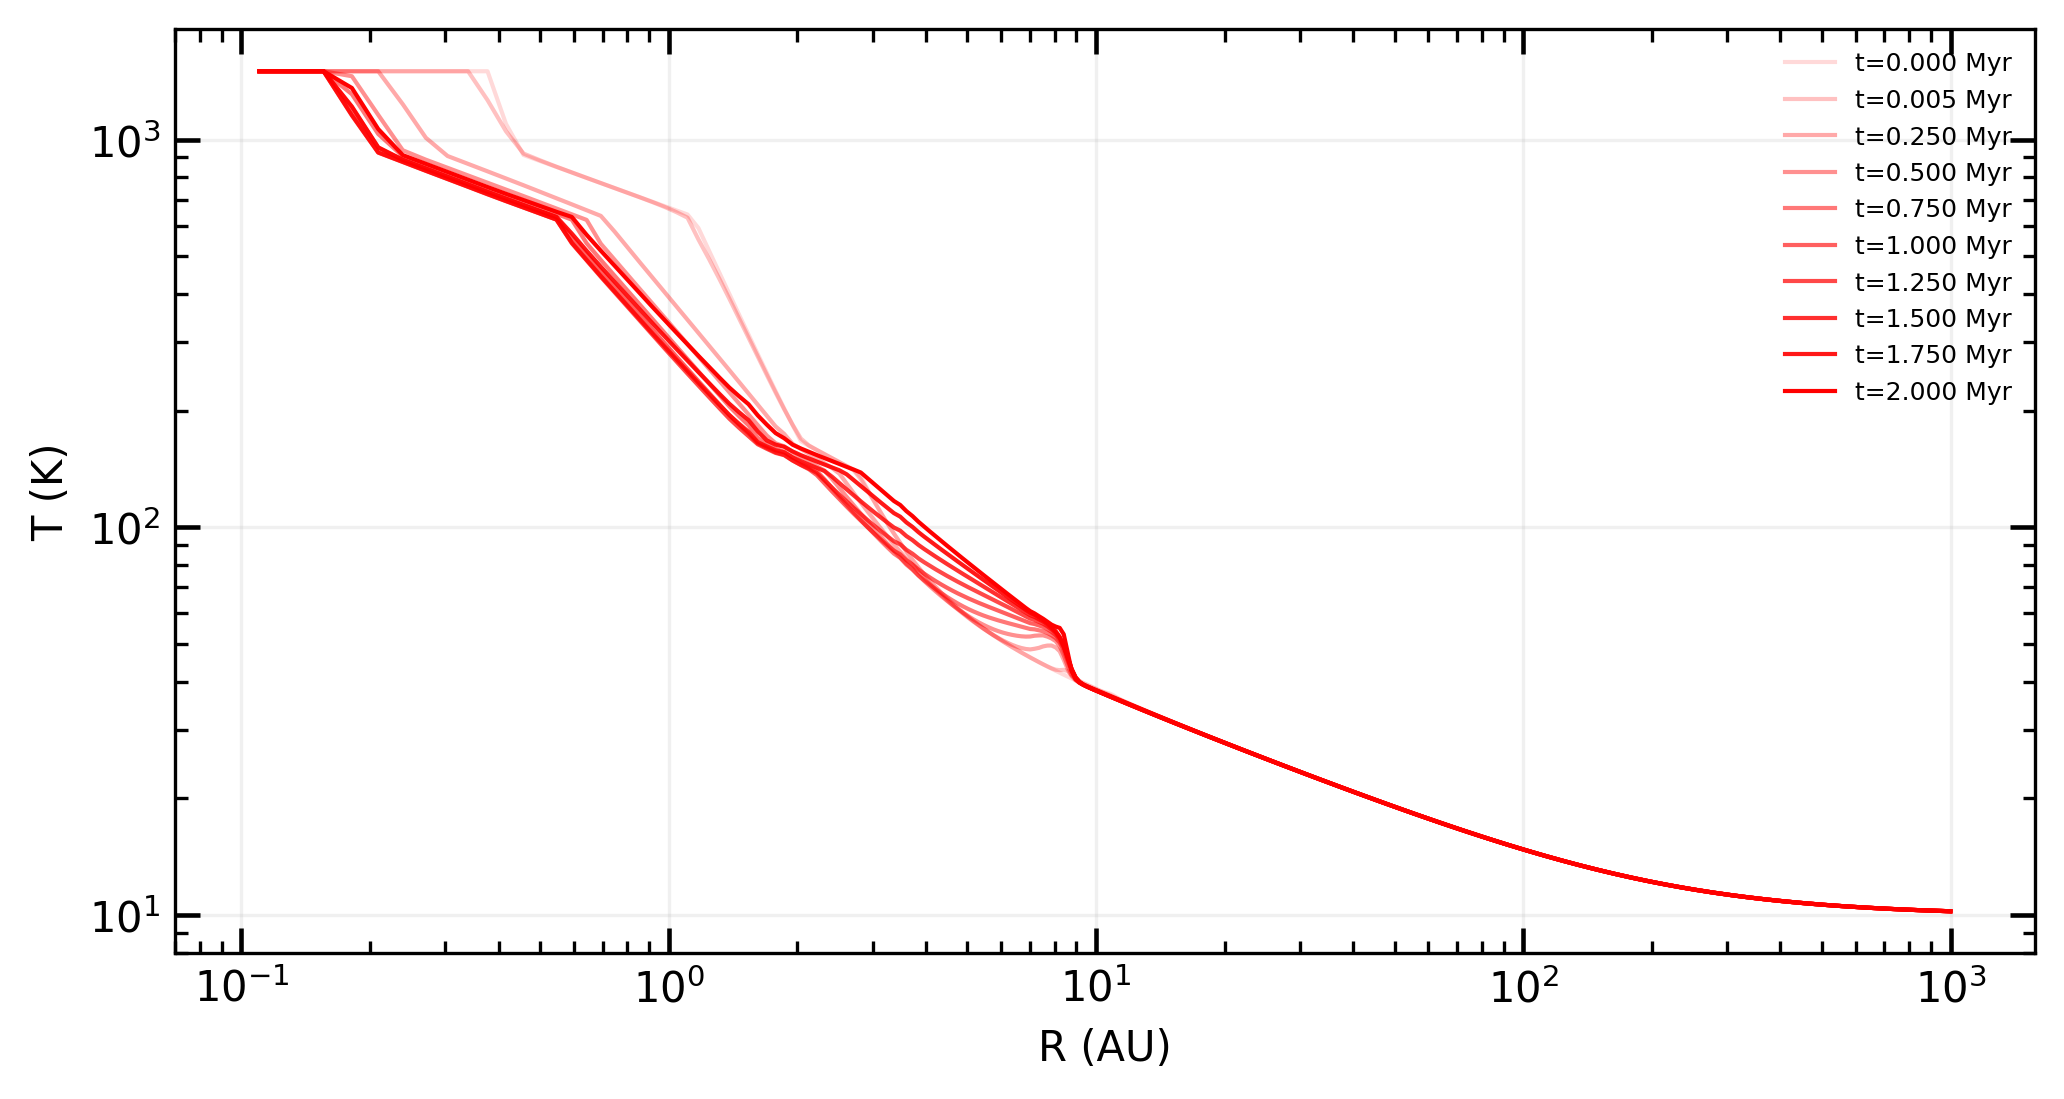

In [32]:
fig, ax = plt.subplots(figsize=(8, 4), dpi = 300)
alphas = np.array([1.0]) if len(idx) == 1 else np.linspace(0.15, 1.0, len(closest_indices))# ticks on all four sides
ax.tick_params(axis="both", which="major", direction="in", length=6, width=1.1, top=True, right=True)
ax.tick_params(axis="both", which="minor", direction="in", length=3, width=0.8, top=True, right=True)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(True, which="major", alpha=0.18, lw=0.8)
ax.set_xlabel('R (AU)')
ax.set_ylabel('T (K)')
#ax.set_xlim(8,10)
#ax.set_ylim(0.9,1.1)

xdata = crR
ydata = crT
for a_i, i in enumerate(range(0,10)):
    ax.loglog(xdata, ydata[i], linestyle='solid', color='red', alpha=alphas[a_i],
                label=rf"t={crtsnap[i]:.3f} Myr", lw = 1.0)

ax.legend(frameon=False, fontsize=6, loc="best")